Calculates Floquet on Young dataset

# Functions

## old - overall

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from scipy import signal
from sklearn.utils import resample

def apply_lowpass_filter(data: np.ndarray, 
                        fs: float, 
                        cutoff: float = 8.0,
                        order: int = 4) -> np.ndarray:
    """
    Apply zero-lag Butterworth low-pass filter to data.
    
    Parameters:
    -----------
    data : array of shape (n_samples, n_axes)
    fs : sampling frequency in Hz
    cutoff : cutoff frequency in Hz (default 8 Hz)
    order : filter order (default 4)
    
    Returns:
    --------
    filtered_data : array of same shape as input
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    
    # Design Butterworth filter
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    
    # Apply zero-lag filtering (filtfilt)
    filtered_data = np.zeros_like(data)
    for ax in range(data.shape[1]):
        filtered_data[:, ax] = signal.filtfilt(b, a, data[:, ax])
    
    return filtered_data


def compute_floquet_from_events(com_da: xr.DataArray,
                                events_df: pd.DataFrame,
                                channel: str = "COM",
                                axes: list = ["x", "y", "z"],
                                normalization_points: int = 101,
                                rcond: float = 1e-6,
                                phase_dependent: bool = False,
                                plot_spectrum: bool = False,
                                use_same_side: bool = True,
                                trim_cycles: int = 5,
                                bootstrap_n: int = 100,
                                bootstrap_ci: float = 95.0,
                                lowpass_cutoff: float = 8.0,
                                min_cycles_required: int = 150) -> dict:
    """
    Compute Floquet multipliers from a continuous COM DataArray with improved methodology.
    
    Parameters:
    -----------
    com_da : xr.DataArray
        COM trajectory data
    events_df : pd.DataFrame
        Events dataframe with 'time', 'label', and 'context' columns
    channel : str
        Channel to analyze (default "COM")
    axes : list
        Axes to include (default ["x", "y", "z"])
    normalization_points : int
        Number of points for time normalization (default 101)
    rcond : float
        Regularization parameter for pseudo-inverse (default 1e-6)
    phase_dependent : bool
        Whether to compute phase-dependent stability (default False)
    plot_spectrum : bool
        Whether to plot eigenvalue spectrum (default False)
    use_same_side : bool
        Whether to use same-side Poincaré sections (default True)
    trim_cycles : int
        Number of cycles to trim from start/end (default 5)
    bootstrap_n : int
        Number of bootstrap iterations (default 100)
    bootstrap_ci : float
        Confidence interval percentage (default 95.0)
    lowpass_cutoff : float
        Low-pass filter cutoff frequency in Hz (default 8.0)
    min_cycles_required : int
        Minimum number of cycles required (default 150)
    
    Returns:
    --------
    results : dict
        Dictionary containing:
        - 'max_floquet': Maximum Floquet multiplier (or array if phase-dependent)
        - 'confidence_interval': Bootstrap confidence interval (if applicable)
        - 'n_cycles_used': Number of cycles used in analysis
        - 'trimmed_cycles': Number of cycles trimmed
    """
    # 1) Extract all Foot Strike times & contexts
    df_fs = events_df[events_df['label'] == 'Foot Strike'].copy()
    df_fs = df_fs[['time','context']].sort_values('time')
    strike_times = df_fs['time'].values
    strike_context = df_fs['context'].values
    
    # 2) Determine which strikes to use based on same-side setting
    if use_same_side:
        # Use only Left→Left or Right→Right transitions
        # Choose the side with more strikes
        left_indices = np.where(strike_context == 'Left')[0]
        right_indices = np.where(strike_context == 'Right')[0]
        
        if len(left_indices) >= len(right_indices):
            use_indices = left_indices
            side_used = 'Left'
        else:
            use_indices = right_indices
            side_used = 'Right'
        
        # Create stride segments from same-side strikes
        stride_starts = use_indices[:-1]
        stride_ends = use_indices[1:]
        print(f"Using {side_used}-to-{side_used} strides: {len(stride_starts)} strides")
    else:
        # Use all consecutive strikes (original behavior)
        stride_starts = np.arange(len(strike_times) - 1)
        stride_ends = stride_starts + 1
        print(f"Using all consecutive strikes: {len(stride_starts)} strides")
    
    # 3) Build raw segments
    raw_segs = []
    raw_ts = []
    raw_contexts = []
    
    for i, (start_idx, end_idx) in enumerate(zip(stride_starts, stride_ends)):
        t0 = strike_times[start_idx]
        t1 = strike_times[end_idx]
        
        seg = (com_da
               .sel(channel=channel, axis=axes)
               .sel(time=slice(t0, t1))
               .transpose('time', 'axis'))
        t = seg.time.values
        
        if t.size < 10:  # Skip very short segments
            continue
            
        raw_segs.append(seg.values)
        raw_ts.append(t)
        raw_contexts.append(strike_context[start_idx])
    
    n_cycles = len(raw_segs)
    n_axes = len(axes)
    state_dim = 2 * n_axes
    
    # Check if we have enough cycles
    if n_cycles < min_cycles_required:
        print(f"WARNING: Only {n_cycles} cycles available, recommended minimum is {min_cycles_required}")
    
    if n_cycles < state_dim + 1 + 2*trim_cycles:
        raise ValueError(f"Need ≥{state_dim + 1 + 2*trim_cycles} valid strides, got {n_cycles}")
    
    # 4) Apply low-pass filter to each segment before normalization
    filtered_segs = []
    for i, (seg_vals, t) in enumerate(zip(raw_segs, raw_ts)):
        # Estimate sampling frequency
        fs = 1.0 / np.mean(np.diff(t))
        
        # Apply filter
        filtered_seg = apply_lowpass_filter(seg_vals, fs, lowpass_cutoff)
        filtered_segs.append(filtered_seg)
    
    # 5) Time-normalize each cycle
    M = normalization_points
    norm_t = np.linspace(0, 1, M)
    com_norm = np.zeros((n_cycles, M, n_axes), dtype=float)
    
    for i, (seg_vals, t) in enumerate(zip(filtered_segs, raw_ts)):
        t_norm = (t - t[0]) / (t[-1] - t[0])
        for ax in range(n_axes):
            com_norm[i, :, ax] = np.interp(norm_t, t_norm, seg_vals[:, ax])
    
    dt = 1.0 / (M - 1)
    
    # 6) Trim first and last cycles
    if trim_cycles > 0:
        com_norm = com_norm[trim_cycles:-trim_cycles]
        raw_contexts = raw_contexts[trim_cycles:-trim_cycles]
        n_cycles_trimmed = n_cycles - 2*trim_cycles
        print(f"Trimmed {trim_cycles} cycles from start/end, using {n_cycles_trimmed} cycles")
    else:
        n_cycles_trimmed = n_cycles
    
    # 7) Central-difference velocity
    vel_norm = np.zeros_like(com_norm)
    vel_norm[:, 1:-1, :] = (com_norm[:, 2:, :] - com_norm[:, :-2, :]) / (2 * dt)
    vel_norm[:, 0, :]     = (com_norm[:, 1, :] - com_norm[:, 0, :])   / dt
    vel_norm[:, -1, :]    = (com_norm[:, -1, :] - com_norm[:, -2, :]) / dt
    
    # 8) Jacobian & eigenvalue helper with bootstrap
    def _estimate_jacobian_and_max(S_pos, S_vel, return_jacobian=False):
        S = np.hstack([S_pos, S_vel])
        X = S[:-1, :]
        Y = S[1:,  :]
        Sbar = S.mean(axis=0)
        dX = (X - Sbar).T
        dY = (Y - Sbar).T
        
        try:
            pinv_dX = np.linalg.pinv(dX, rcond=rcond)
            J = dY @ pinv_dX
        except np.linalg.LinAlgError:
            lam = rcond * np.trace(dX @ dX.T)
            J = dY @ dX.T @ np.linalg.inv(dX @ dX.T + lam * np.eye(dX.shape[0]))
        
        eigs = np.linalg.eigvals(J)
        
        if plot_spectrum:
            mags = np.abs(eigs)
            plt.figure(figsize=(8, 5))
            plt.plot(np.arange(len(mags)), mags, 'o-', markersize=8)
            plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
            plt.ylim(0, 1.2)
            plt.xlabel('Mode #')
            plt.ylabel('|λ|')
            plt.title('Floquet Eigenvalue Spectrum')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
            plt.close()
        
        if return_jacobian:
            return eigs, np.max(np.abs(eigs)), J
        else:
            return eigs, np.max(np.abs(eigs))
    
    def _bootstrap_floquet(S_pos, S_vel, n_boot=100, ci=95.0):
        """Compute bootstrap confidence interval for max Floquet multiplier."""
        n_samples = S_pos.shape[0]
        max_lams = []
        
        for _ in range(n_boot):
            # Resample with replacement
            indices = resample(np.arange(n_samples), n_samples=n_samples)
            S_pos_boot = S_pos[indices]
            S_vel_boot = S_vel[indices]
            
            try:
                _, max_lam = _estimate_jacobian_and_max(S_pos_boot, S_vel_boot)
                max_lams.append(max_lam)
            except:
                continue
        
        if len(max_lams) > 0:
            max_lams = np.array(max_lams)
            ci_low = np.percentile(max_lams, (100 - ci) / 2)
            ci_high = np.percentile(max_lams, 100 - (100 - ci) / 2)
            return np.mean(max_lams), (ci_low, ci_high)
        else:
            return None, (None, None)
    
    # 9) Compute results
    if not phase_dependent:
        S_pos = com_norm[:, 0, :]
        S_vel = vel_norm[:, 0, :]
        
        # Compute main result
        _, max_lam = _estimate_jacobian_and_max(S_pos, S_vel)
        
        # Bootstrap confidence interval
        mean_lam, (ci_low, ci_high) = _bootstrap_floquet(S_pos, S_vel, bootstrap_n, bootstrap_ci)
        
        # Poincaré plot
        S = np.hstack([S_pos, S_vel])
        xk = S[:-1, 0]
        xk1 = S[1:, 0]
        mn, mx = min(xk.min(), xk1.min()), max(xk.max(), xk1.max())
        
        plt.figure(figsize=(6, 6))
        
        if use_same_side:
            plt.scatter(xk, xk1, s=30, alpha=0.6, c='blue', label=f'{side_used}→{side_used}')
        else:
            mask_L = np.array(raw_contexts[:-1]) == 'Left'
            mask_R = ~mask_L
            plt.scatter(xk[mask_L], xk1[mask_L], s=30, alpha=0.6, label='Left→Right')
            plt.scatter(xk[mask_R], xk1[mask_R], s=30, alpha=0.6, label='Right→Left')
        
        plt.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5)
        plt.xlabel(r'$x_k$ at strike $k$')
        plt.ylabel(r'$x_{k+1}$ at strike $k+1$')
        plt.title(f'Poincaré Map (COM x-position)\nMax |λ| = {max_lam:.3f} [{ci_low:.3f}, {ci_high:.3f}]')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        plt.show()
        plt.close()
        
        return {
            'max_floquet': float(max_lam),
            'confidence_interval': (ci_low, ci_high),
            'n_cycles_used': n_cycles_trimmed,
            'trimmed_cycles': trim_cycles,
            'side_used': side_used if use_same_side else 'both'
        }
    
    else:
        # Phase-dependent analysis
        max_vs_phi = np.zeros(M)
        ci_low_vs_phi = np.zeros(M)
        ci_high_vs_phi = np.zeros(M)
        
        for phi in range(M):
            S_pos = com_norm[:, phi, :]
            S_vel = vel_norm[:, phi, :]
            
            _, max_vs_phi[phi] = _estimate_jacobian_and_max(S_pos, S_vel)
            
            # Bootstrap for this phase
            _, (ci_low, ci_high) = _bootstrap_floquet(S_pos, S_vel, bootstrap_n, bootstrap_ci)
            ci_low_vs_phi[phi] = ci_low if ci_low is not None else max_vs_phi[phi]
            ci_high_vs_phi[phi] = ci_high if ci_high is not None else max_vs_phi[phi]
        
        phases = np.linspace(0, 100, M)
        
        plt.figure(figsize=(10, 6))
        plt.plot(phases, max_vs_phi, '-', linewidth=2, label='Mean')
        plt.fill_between(phases, ci_low_vs_phi, ci_high_vs_phi, alpha=0.3, label=f'{bootstrap_ci}% CI')
        plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
        plt.xlabel('Gait phase (%)')
        plt.ylabel('Max |λ|')
        plt.title(f'Phase-dependent Floquet Multipliers (n={n_cycles_trimmed} cycles)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()
        
        return {
            'max_floquet': max_vs_phi,
            'confidence_interval': (ci_low_vs_phi, ci_high_vs_phi),
            'n_cycles_used': n_cycles_trimmed,
            'trimmed_cycles': trim_cycles,
            'side_used': side_used if use_same_side else 'both'
        }


def plot_limit_cycle_2d(com_norm: np.ndarray,
                        vel_norm: np.ndarray,
                        rcond: float = 1e-6):
    """
    Plot the 2D limit cycle in [x, xdot] plus the dominant Floquet mode arrow.
    
    Parameters
    ----------
    com_norm : array (n_cycles, M, 3)
        Time‐normalized COM positions (x,y,z).
    vel_norm : array (n_cycles, M, 3)
        Time‐normalized COM velocities (xdot,ydot,zdot).
    rcond : float
        Pseudo‐inverse cutoff.
    """
    # 1) Mean cycle in (x, xdot)
    mean_x    = com_norm.mean(axis=0)[:,1]   # mean x
    mean_xdot = vel_norm.mean(axis=0)[:,1]   # mean xdot
    
    # 2) Build Jacobian at phase=0
    S_pos = com_norm[:,0,:]   # (n_cycles,3)
    S_vel = vel_norm[:,0,:]
    S_cat = np.hstack([S_pos, S_vel])  # (n_cycles,6)
    
    Xmat, Ymat = S_cat[:-1], S_cat[1:]
    Sbar = S_cat.mean(axis=0)
    dX = (Xmat - Sbar).T
    dY = (Ymat - Sbar).T
    J = dY @ pinv(dX, rcond=rcond)
    
    # 3) Eigen‐decomposition & pick dominant stable mode
    vals, vecs = eig(J)
    mags = np.abs(vals)
    
    # ignore neutral (closest to 1), take max of the rest
    neutral = np.argmin(np.abs(mags-1.0))
    idx = np.argsort(mags)[-2] if neutral==np.argmax(mags) else np.argmax(mags)
    
    v = np.real(vecs[:,idx])   # length‐6
    
    # 4) Project that eigenvector into (x, xdot)
    # v = [vx,vy,vz, vxdot, vydot, vzdot]
    eig2 = np.array([v[1], v[4]])
    eig2 = eig2/np.linalg.norm(eig2)*0.1   # scale for visibility
    
    # 5) Plot
    plt.figure(figsize=(8,6))
    
    # Plot mean cycle
    plt.plot(mean_x, mean_xdot, 'k-', lw=2.5, label='Mean limit cycle')
    
    # Mark Poincaré section
    plt.scatter(mean_x[0], mean_xdot[0], c='red', s=120, zorder=5, 
                edgecolors='darkred', linewidths=2, label='Poincaré section (heel-strike)')
    
    # Plot dominant Floquet mode as arrow
    plt.arrow(mean_x[0], mean_xdot[0],
              eig2[0], eig2[1],
              head_width=0.008, head_length=0.015,
              fc='blue', ec='blue', lw=2.5, 
              label=f'Dominant Floquet mode (|λ|={mags[idx]:.3f})')
    
    # Add opposite direction arrow for visualization
    plt.arrow(mean_x[0], mean_xdot[0],
              -eig2[0], -eig2[1],
              head_width=0.008, head_length=0.015,
              fc='lightblue', ec='lightblue', lw=2, alpha=0.5)
    
    plt.xlabel('Antiposterior Position x (m)', fontsize=12)
    plt.ylabel(r'AP Velocity $\dot{x}$ (m/s)', fontsize=12)
    plt.title('2D Gait Limit Cycle & Dominant Floquet Mode', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    # Print additional information
    print(f"\nLimit Cycle Analysis:")
    print(f"- Dominant Floquet multiplier: |λ| = {mags[idx]:.4f}")
    print(f"- Eigenvector direction in (x, ẋ): [{eig2[0]:.3f}, {eig2[1]:.3f}]")
    print(f"- Mean stride length: {mean_x.max() - mean_x.min():.3f} m")
    print(f"- Peak forward velocity: {mean_xdot.max():.3f} m/s")


def extract_normalized_data_with_filter(com_window, df_window, 
                                       use_same_side=True, 
                                       side_used='Right',
                                       trim_cycles=0,
                                       lowpass_cutoff=8.0,
                                       normalization_points=101):
    """
    Extract normalized and filtered COM data matching the Floquet analysis preprocessing.
    
    Returns:
    --------
    com_norm : array (n_cycles, M, 3)
        Time-normalized COM positions
    vel_norm : array (n_cycles, M, 3)  
        Time-normalized COM velocities
    """
    # Get foot strike events
    df_fs = df_window.query("label=='Foot Strike'")[['time','context']].sort_values('time')
    strike_times = df_fs['time'].values
    strike_context = df_fs['context'].values
    
    # Determine which strikes to use
    if use_same_side:
        # Use only same-side transitions
        side_indices = np.where(strike_context == side_used)[0]
        stride_starts = side_indices[:-1]
        stride_ends = side_indices[1:]
        print(f"Extracting {len(stride_starts)} {side_used}-to-{side_used} strides")
    else:
        stride_starts = np.arange(len(strike_times) - 1)
        stride_ends = stride_starts + 1
    
    # Build raw segments
    raw_segs = []
    raw_ts = []
    com_data = com_window.sel(channel="COM", axis=["x","y","z"])
    
    for i, (start_idx, end_idx) in enumerate(zip(stride_starts, stride_ends)):
        t0 = strike_times[start_idx]
        t1 = strike_times[end_idx]
        
        seg = com_data.sel(time=slice(t0, t1)).transpose('time','axis')
        t = seg.time.values
        
        if t.size < 10:  # Skip very short segments
            continue
            
        raw_segs.append(seg.values)
        raw_ts.append(t)
    
    # Apply low-pass filter to each segment
    filtered_segs = []
    for seg_vals, t in zip(raw_segs, raw_ts):
        fs = 1.0 / np.mean(np.diff(t))
        filtered_seg = apply_lowpass_filter(seg_vals, fs, lowpass_cutoff)
        filtered_segs.append(filtered_seg)
    
    # Time-normalize each cycle
    n_cycles = len(filtered_segs)
    M = normalization_points
    norm_t = np.linspace(0, 1, M)
    
    com_norm = np.zeros((n_cycles, M, 3))
    for idx, (vals, t) in enumerate(zip(filtered_segs, raw_ts)):
        t_norm = (t - t[0])/(t[-1] - t[0])
        for ax in range(3):
            com_norm[idx, :, ax] = np.interp(norm_t, t_norm, vals[:, ax])
    
    # Trim cycles
    if trim_cycles > 0:
        com_norm = com_norm[trim_cycles:-trim_cycles]
        print(f"Trimmed {trim_cycles} cycles from start/end")
    
    # Compute velocities
    dt = 1/(M-1)
    vel_norm = np.zeros_like(com_norm)
    vel_norm[:, 1:-1, :] = (com_norm[:, 2:, :] - com_norm[:, :-2, :])/(2*dt)
    vel_norm[:, 0, :]     = (com_norm[:, 1, :] - com_norm[:, 0, :]) / dt
    vel_norm[:, -1, :]    = (com_norm[:, -1, :] - com_norm[:, -2, :]) / dt
    
    return com_norm, vel_norm

## current - corrected

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig
from scipy import signal
from sklearn.utils import resample

# Include all the helper functions from before
def apply_lowpass_filter(data: np.ndarray, 
                        fs: float, 
                        cutoff: float = 8.0,
                        order: int = 4) -> np.ndarray:
    """Apply zero-lag Butterworth low-pass filter to data."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    
    filtered_data = np.zeros_like(data)
    for ax in range(data.shape[1]):
        filtered_data[:, ax] = signal.filtfilt(b, a, data[:, ax])
    
    return filtered_data


def compute_floquet_from_events(com_da: xr.DataArray,
                                events_df: pd.DataFrame,
                                channel: str = "COM",
                                axes: list = ["x", "y", "z"],
                                normalization_points: int = 101,
                                rcond: float = 1e-6,
                                phase_dependent: bool = False,
                                plot_spectrum: bool = False,
                                use_same_side: bool = True,
                                force_side: str = None,
                                trim_cycles: int = 5,
                                bootstrap_n: int = 100,
                                bootstrap_ci: float = 95.0,
                                lowpass_cutoff: float = 8.0,
                                min_cycles_required: int = 150,
                                return_all_eigenvalues: bool = False) -> dict:
    """
    Compute Floquet multipliers with optional forced side selection.
    
    Additional Parameters:
    ---------------------
    force_side : str or None
        If provided ('Left' or 'Right'), forces analysis of that specific side
    return_all_eigenvalues : bool
        If True, returns all eigenvalues, not just the maximum
    """
    # Extract all Foot Strike times & contexts
    df_fs = events_df[events_df['label'] == 'Foot Strike'].copy()
    df_fs = df_fs[['time','context']].sort_values('time')
    strike_times = df_fs['time'].values
    strike_context = df_fs['context'].values
    
    # Determine which strikes to use based on same-side setting
    if use_same_side:
        left_indices = np.where(strike_context == 'Left')[0]
        right_indices = np.where(strike_context == 'Right')[0]
        
        if force_side is not None:
            # Use the forced side
            side_used = force_side
            use_indices = left_indices if force_side == 'Left' else right_indices
        else:
            # Auto-select the side with more strikes
            if len(left_indices) >= len(right_indices):
                use_indices = left_indices
                side_used = 'Left'
            else:
                use_indices = right_indices
                side_used = 'Right'
        
        # Create stride segments from same-side strikes
        stride_starts = use_indices[:-1]
        stride_ends = use_indices[1:]
        print(f"Using {side_used}-to-{side_used} strides: {len(stride_starts)} strides")
    else:
        # Use all consecutive strikes (original behavior)
        stride_starts = np.arange(len(strike_times) - 1)
        stride_ends = stride_starts + 1
        print(f"Using all consecutive strikes: {len(stride_starts)} strides")
    
    # Build raw segments
    raw_segs = []
    raw_ts = []
    raw_contexts = []
    
    for i, (start_idx, end_idx) in enumerate(zip(stride_starts, stride_ends)):
        t0 = strike_times[start_idx]
        t1 = strike_times[end_idx]
        
        seg = (com_da
               .sel(channel=channel, axis=axes)
               .sel(time=slice(t0, t1))
               .transpose('time', 'axis'))
        t = seg.time.values
        
        if t.size < 10:  # Skip very short segments
            continue
            
        raw_segs.append(seg.values)
        raw_ts.append(t)
        raw_contexts.append(strike_context[start_idx])
    
    n_cycles = len(raw_segs)
    n_axes = len(axes)
    state_dim = 2 * n_axes
    
    # Check if we have enough cycles
    if n_cycles < min_cycles_required:
        print(f"WARNING: Only {n_cycles} cycles available, recommended minimum is {min_cycles_required}")
    
    if n_cycles < state_dim + 1 + 2*trim_cycles:
        raise ValueError(f"Need ≥{state_dim + 1 + 2*trim_cycles} valid strides, got {n_cycles}")
    
    # Apply low-pass filter to each segment before normalization
    filtered_segs = []
    for i, (seg_vals, t) in enumerate(zip(raw_segs, raw_ts)):
        fs = 1.0 / np.mean(np.diff(t))
        filtered_seg = apply_lowpass_filter(seg_vals, fs, lowpass_cutoff)
        filtered_segs.append(filtered_seg)
    
    # Time-normalize each cycle
    M = normalization_points
    norm_t = np.linspace(0, 1, M)
    com_norm = np.zeros((n_cycles, M, n_axes), dtype=float)
    
    for i, (seg_vals, t) in enumerate(zip(filtered_segs, raw_ts)):
        t_norm = (t - t[0]) / (t[-1] - t[0])
        for ax in range(n_axes):
            com_norm[i, :, ax] = np.interp(norm_t, t_norm, seg_vals[:, ax])
    
    dt = 1.0 / (M - 1)
    
    # Trim first and last cycles
    if trim_cycles > 0:
        com_norm = com_norm[trim_cycles:-trim_cycles]
        raw_contexts = raw_contexts[trim_cycles:-trim_cycles]
        n_cycles_trimmed = n_cycles - 2*trim_cycles
        print(f"Trimmed {trim_cycles} cycles from start/end, using {n_cycles_trimmed} cycles")
    else:
        n_cycles_trimmed = n_cycles
    
    # Central-difference velocity
    vel_norm = np.zeros_like(com_norm)
    vel_norm[:, 1:-1, :] = (com_norm[:, 2:, :] - com_norm[:, :-2, :]) / (2 * dt)
    vel_norm[:, 0, :]     = (com_norm[:, 1, :] - com_norm[:, 0, :])   / dt
    vel_norm[:, -1, :]    = (com_norm[:, -1, :] - com_norm[:, -2, :]) / dt
    
    # Jacobian & eigenvalue helper with bootstrap
    def _estimate_jacobian_and_max(S_pos, S_vel, return_jacobian=False):
        S = np.hstack([S_pos, S_vel])
        X = S[:-1, :]
        Y = S[1:,  :]
        Sbar = S.mean(axis=0)
        dX = (X - Sbar).T
        dY = (Y - Sbar).T
        
        try:
            pinv_dX = np.linalg.pinv(dX, rcond=rcond)
            J = dY @ pinv_dX
        except np.linalg.LinAlgError:
            lam = rcond * np.trace(dX @ dX.T)
            J = dY @ dX.T @ np.linalg.inv(dX @ dX.T + lam * np.eye(dX.shape[0]))
        
        eigs = np.linalg.eigvals(J)
        mags = np.abs(eigs)
        
        if plot_spectrum:
            sorted_idx = np.argsort(mags)[::-1]
            sorted_mags = mags[sorted_idx]
            
            plt.figure(figsize=(8, 5))
            plt.plot(np.arange(len(sorted_mags)), sorted_mags, 'o-', markersize=8)
            plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
            plt.ylim(0, 1.2)
            plt.xlabel('Mode #')
            plt.ylabel('|λ|')
            
            # Add axis labels if analyzing single or all axes
            if n_axes == 1:
                axis_name = axes[0]
                axis_label = {'x': 'Medio-lateral', 'y': 'Anterior-posterior', 'z': 'Vertical'}[axis_name]
                plt.title(f'Floquet Eigenvalue Spectrum ({axis_label} axis, {side_used} side)')
            else:
                plt.title(f'Floquet Eigenvalue Spectrum (Combined 6D, {side_used} side)')
            
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
            plt.close()
        
        if return_all_eigenvalues:
            sorted_idx = np.argsort(mags)[::-1]
            return eigs[sorted_idx], mags[sorted_idx], J if return_jacobian else None
        elif return_jacobian:
            return eigs, np.max(mags), J
        else:
            return eigs, np.max(mags)
    
    def _bootstrap_floquet(S_pos, S_vel, n_boot=100, ci=95.0):
        """Compute bootstrap confidence interval for max Floquet multiplier."""
        n_samples = S_pos.shape[0]
        max_lams = []
        
        for _ in range(n_boot):
            indices = resample(np.arange(n_samples), n_samples=n_samples)
            S_pos_boot = S_pos[indices]
            S_vel_boot = S_vel[indices]
            
            try:
                _, max_lam = _estimate_jacobian_and_max(S_pos_boot, S_vel_boot)
                max_lams.append(max_lam)
            except:
                continue
        
        if len(max_lams) > 0:
            max_lams = np.array(max_lams)
            ci_low = np.percentile(max_lams, (100 - ci) / 2)
            ci_high = np.percentile(max_lams, 100 - (100 - ci) / 2)
            return np.mean(max_lams), (ci_low, ci_high)
        else:
            return None, (None, None)
    
    # Compute results
    if not phase_dependent:
        S_pos = com_norm[:, 0, :]
        S_vel = vel_norm[:, 0, :]
        
        # Compute main result
        if return_all_eigenvalues:
            eigs, mags = _estimate_jacobian_and_max(S_pos, S_vel, return_jacobian=False)[:2]
            max_lam = mags[0]  # Already sorted by magnitude
        else:
            _, max_lam = _estimate_jacobian_and_max(S_pos, S_vel)
        
        # Bootstrap confidence interval
        mean_lam, (ci_low, ci_high) = _bootstrap_floquet(S_pos, S_vel, bootstrap_n, bootstrap_ci)
        
        # Poincaré plot
        if n_axes == 1:
            # For single axis analysis, plot in position-velocity space
            S = np.hstack([S_pos, S_vel])
            xk = S[:-1, 0]
            xk1 = S[1:, 0]
            
            axis_labels = {
                'x': ('Medio-lateral', 'ML'),
                'y': ('Anterior-posterior', 'AP'),
                'z': ('Vertical', 'Vert')
            }
            full_name, short_name = axis_labels[axes[0]]
            
            plt.figure(figsize=(6, 6))
            color = 'blue' if side_used == 'Right' else 'red'
            plt.scatter(xk, xk1, s=30, alpha=0.6, c=color, label=f'{side_used}→{side_used}')
            
            mn, mx = min(xk.min(), xk1.min()), max(xk.max(), xk1.max())
            plt.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5)
            plt.xlabel(f'{short_name} position at strike k (m)')
            plt.ylabel(f'{short_name} position at strike k+1 (m)')
            plt.title(f'Poincaré Map ({full_name}, {side_used} side)\nMax |λ| = {max_lam:.3f} [{ci_low:.3f}, {ci_high:.3f}]')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.axis('equal')
            plt.show()
            plt.close()
        else:
            # For multi-axis analysis, plot AP position (y-axis)
            S = np.hstack([S_pos, S_vel])
            xk = S[:-1, 1]  # Use y-axis (AP) for visualization
            xk1 = S[1:, 1]
            
            plt.figure(figsize=(6, 6))
            color = 'blue' if side_used == 'Right' else 'red'
            plt.scatter(xk, xk1, s=30, alpha=0.6, c=color, label=f'{side_used}→{side_used}')
            
            mn, mx = min(xk.min(), xk1.min()), max(xk.max(), xk1.max())
            plt.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5)
            plt.xlabel('AP position at strike k (m)')
            plt.ylabel('AP position at strike k+1 (m)')
            plt.title(f'Poincaré Map (Combined 6D, {side_used} side)\nMax |λ| = {max_lam:.3f} [{ci_low:.3f}, {ci_high:.3f}]')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.axis('equal')
            plt.show()
            plt.close()
        
        result = {
            'max_floquet': float(max_lam),
            'confidence_interval': (ci_low, ci_high),
            'n_cycles_used': n_cycles_trimmed,
            'trimmed_cycles': trim_cycles,
            'side_used': side_used if use_same_side else 'both',
            'axes_analyzed': axes
        }
        
        if return_all_eigenvalues:
            result['all_eigenvalues'] = eigs
            result['all_magnitudes'] = mags
        
        return result
    
    else:
        # Phase-dependent analysis
        max_vs_phi = np.zeros(M)
        ci_low_vs_phi = np.zeros(M)
        ci_high_vs_phi = np.zeros(M)
        
        for phi in range(M):
            S_pos = com_norm[:, phi, :]
            S_vel = vel_norm[:, phi, :]
            
            _, max_vs_phi[phi] = _estimate_jacobian_and_max(S_pos, S_vel)
            
            # Bootstrap for this phase
            _, (ci_low, ci_high) = _bootstrap_floquet(S_pos, S_vel, bootstrap_n, bootstrap_ci)
            ci_low_vs_phi[phi] = ci_low if ci_low is not None else max_vs_phi[phi]
            ci_high_vs_phi[phi] = ci_high if ci_high is not None else max_vs_phi[phi]
        
        phases = np.linspace(0, 100, M)
        
        plt.figure(figsize=(10, 6))
        plt.plot(phases, max_vs_phi, '-', linewidth=2, label=f'Mean ({side_used} side)')
        plt.fill_between(phases, ci_low_vs_phi, ci_high_vs_phi, alpha=0.3, label=f'{bootstrap_ci}% CI')
        plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
        plt.xlabel('Gait phase (%)')
        plt.ylabel('Max |λ|')
        
        if n_axes == 1:
            axis_name = axes[0]
            axis_label = {'x': 'Medio-lateral', 'y': 'Anterior-posterior', 'z': 'Vertical'}[axis_name]
            plt.title(f'Phase-dependent Floquet ({axis_label}, {side_used} side, n={n_cycles_trimmed})')
        else:
            plt.title(f'Phase-dependent Floquet (Combined 6D, {side_used} side, n={n_cycles_trimmed})')
        
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()
        
        return {
            'max_floquet': max_vs_phi,
            'confidence_interval': (ci_low_vs_phi, ci_high_vs_phi),
            'n_cycles_used': n_cycles_trimmed,
            'trimmed_cycles': trim_cycles,
            'side_used': side_used if use_same_side else 'both',
            'axes_analyzed': axes
        }


def compute_floquet_per_axis(com_da: xr.DataArray,
                            events_df: pd.DataFrame,
                            channel: str = "COM",
                            **kwargs):
    """
    Compute Floquet multipliers for each axis separately and combined.
    
    Axes mapping:
    - x: Medio-lateral (ML) - side-to-side
    - y: Anterior-posterior (AP) - forward/backward  
    - z: Vertical (Vert) - up/down
    
    Returns:
    --------
    dict with keys 'x', 'y', 'z', 'combined', each containing full results
    """
    results = {}
    
    # Compute for each individual axis
    print("\n" + "="*60)
    print("COMPUTING PER-AXIS FLOQUET MULTIPLIERS")
    print("="*60)
    
    for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
        print(f"\nAnalyzing {name} ({axis}) axis...")
        axis_result = compute_floquet_from_events(
            com_da=com_da,
            events_df=events_df,
            channel=channel,
            axes=[axis],  # Single axis only
            **kwargs
        )
        results[axis] = axis_result
    
    # Also compute combined (original behavior)
    print(f"\nAnalyzing Combined 6D state space...")
    results['combined'] = compute_floquet_from_events(
        com_da=com_da,
        events_df=events_df,
        channel=channel,
        axes=['x', 'y', 'z'],
        **kwargs
    )
    
    return results


def plot_limit_cycle_2d(com_norm: np.ndarray,
                        vel_norm: np.ndarray,
                        rcond: float = 1e-6):
    """
    Plot the 2D limit cycle in [y, ydot] (AP direction) plus the dominant Floquet mode arrow.
    
    Note: Using y-axis (anterior-posterior) for visualization as it's the primary 
    direction of progression in gait.
    """
    # Mean cycle in (y, ydot) - using AP direction
    mean_y    = com_norm.mean(axis=0)[:,1]   # mean y (AP)
    mean_ydot = vel_norm.mean(axis=0)[:,1]   # mean ydot (AP velocity)
    
    # Build Jacobian at phase=0
    S_pos = com_norm[:,0,:]   # (n_cycles,3)
    S_vel = vel_norm[:,0,:]
    S_cat = np.hstack([S_pos, S_vel])  # (n_cycles,6)
    
    Xmat, Ymat = S_cat[:-1], S_cat[1:]
    Sbar = S_cat.mean(axis=0)
    dX = (Xmat - Sbar).T
    dY = (Ymat - Sbar).T
    J = dY @ pinv(dX, rcond=rcond)
    
    # Eigen-decomposition & pick dominant stable mode
    vals, vecs = eig(J)
    mags = np.abs(vals)
    
    # ignore neutral (closest to 1), take max of the rest
    neutral = np.argmin(np.abs(mags-1.0))
    idx = np.argsort(mags)[-2] if neutral==np.argmax(mags) else np.argmax(mags)
    
    v = np.real(vecs[:,idx])   # length-6
    
    # Project that eigenvector into (y, ydot) - AP direction
    # v = [vx,vy,vz, vxdot, vydot, vzdot]
    eig2 = np.array([v[1], v[4]])  # y and ydot components
    eig2 = eig2/np.linalg.norm(eig2)*0.1   # scale for visibility
    
    # Plot
    plt.figure(figsize=(8,6))
    
    # Plot mean cycle
    plt.plot(mean_y, mean_ydot, 'k-', lw=2.5, label='Mean limit cycle')
    
    # Mark Poincaré section
    plt.scatter(mean_y[0], mean_ydot[0], c='red', s=120, zorder=5, 
                edgecolors='darkred', linewidths=2, label='Poincaré section (heel-strike)')
    
    # Plot dominant Floquet mode as arrow
    plt.arrow(mean_y[0], mean_ydot[0],
              eig2[0], eig2[1],
              head_width=0.008, head_length=0.015,
              fc='blue', ec='blue', lw=2.5, 
              label=f'Dominant Floquet mode (|λ|={mags[idx]:.3f})')
    
    # Add opposite direction arrow for visualization
    plt.arrow(mean_y[0], mean_ydot[0],
              -eig2[0], -eig2[1],
              head_width=0.008, head_length=0.015,
              fc='lightblue', ec='lightblue', lw=2, alpha=0.5)
    
    plt.xlabel('Anterior-Posterior Position (m)', fontsize=12)
    plt.ylabel(r'AP Velocity (m/s)', fontsize=12)
    plt.title('2D Gait Limit Cycle & Dominant Floquet Mode', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    # Print additional information
    print(f"\nLimit Cycle Analysis:")
    print(f"- Dominant Floquet multiplier: |λ| = {mags[idx]:.4f}")
    print(f"- Eigenvector direction in (y, ẏ): [{eig2[0]:.3f}, {eig2[1]:.3f}]")
    print(f"- Mean stride length: {mean_y.max() - mean_y.min():.3f} m")
    print(f"- Peak forward velocity: {mean_ydot.max():.3f} m/s")


def extract_normalized_data_with_filter(com_window, df_window, 
                                       use_same_side=True, 
                                       side_used='Right',
                                       trim_cycles=5,
                                       lowpass_cutoff=8.0,
                                       normalization_points=101):
    """Extract normalized and filtered COM data matching the Floquet analysis preprocessing."""
    # Get foot strike events
    df_fs = df_window.query("label=='Foot Strike'")[['time','context']].sort_values('time')
    strike_times = df_fs['time'].values
    strike_context = df_fs['context'].values
    
    # Determine which strikes to use
    if use_same_side:
        side_indices = np.where(strike_context == side_used)[0]
        stride_starts = side_indices[:-1]
        stride_ends = side_indices[1:]
        print(f"Extracting {len(stride_starts)} {side_used}-to-{side_used} strides")
    else:
        stride_starts = np.arange(len(strike_times) - 1)
        stride_ends = stride_starts + 1
    
    # Build raw segments
    raw_segs = []
    raw_ts = []
    com_data = com_window.sel(channel="COM", axis=["x","y","z"])
    
    for i, (start_idx, end_idx) in enumerate(zip(stride_starts, stride_ends)):
        t0 = strike_times[start_idx]
        t1 = strike_times[end_idx]
        
        seg = com_data.sel(time=slice(t0, t1)).transpose('time','axis')
        t = seg.time.values
        
        if t.size < 10:
            continue
            
        raw_segs.append(seg.values)
        raw_ts.append(t)
    
    # Apply low-pass filter to each segment
    filtered_segs = []
    for seg_vals, t in zip(raw_segs, raw_ts):
        fs = 1.0 / np.mean(np.diff(t))
        filtered_seg = apply_lowpass_filter(seg_vals, fs, lowpass_cutoff)
        filtered_segs.append(filtered_seg)
    
    # Time-normalize each cycle
    n_cycles = len(filtered_segs)
    M = normalization_points
    norm_t = np.linspace(0, 1, M)
    
    com_norm = np.zeros((n_cycles, M, 3))
    for idx, (vals, t) in enumerate(zip(filtered_segs, raw_ts)):
        t_norm = (t - t[0])/(t[-1] - t[0])
        for ax in range(3):
            com_norm[idx, :, ax] = np.interp(norm_t, t_norm, vals[:, ax])
    
    # Trim cycles
    if trim_cycles > 0 and n_cycles > 2*trim_cycles:
        com_norm = com_norm[trim_cycles:-trim_cycles]
        print(f"Trimmed {trim_cycles} cycles from start/end")
    
    # Compute velocities
    dt = 1/(M-1)
    vel_norm = np.zeros_like(com_norm)
    vel_norm[:, 1:-1, :] = (com_norm[:, 2:, :] - com_norm[:, :-2, :])/(2*dt)
    vel_norm[:, 0, :]     = (com_norm[:, 1, :] - com_norm[:, 0, :]) / dt
    vel_norm[:, -1, :]    = (com_norm[:, -1, :] - com_norm[:, -2, :]) / dt
    
    return com_norm, vel_norm

# Patient 13

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 11.96s to 287.53s (all 179 R_FS)
Using 356 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 178 strides


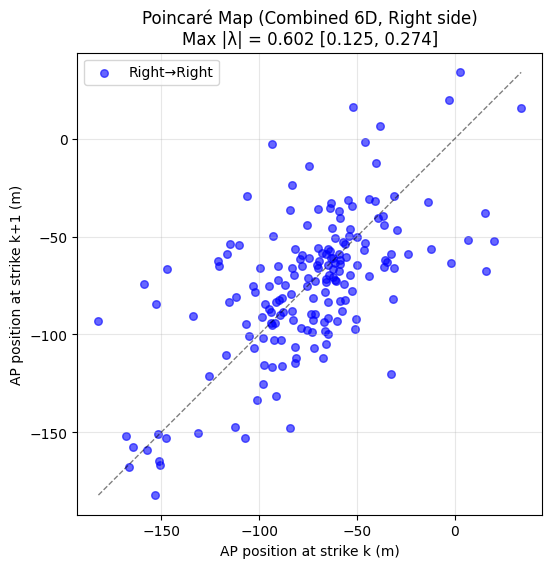


Combined (6D): λ = 0.6023 [0.1246, 0.2739]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 178 strides


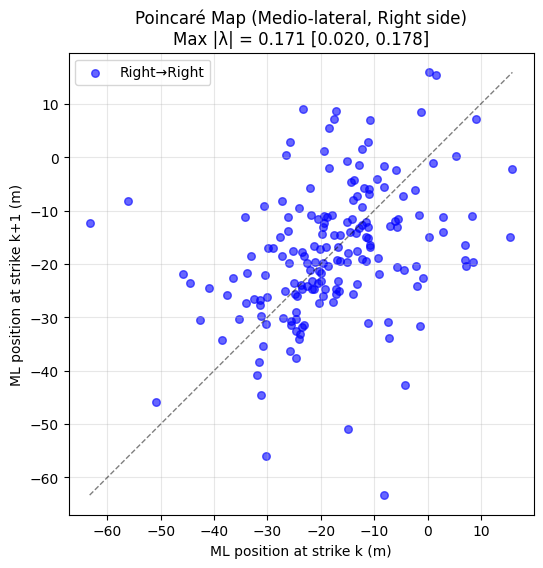


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 178 strides


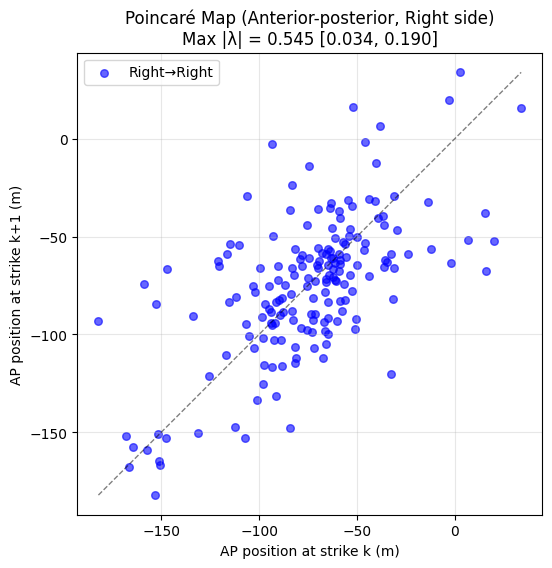


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 178 strides


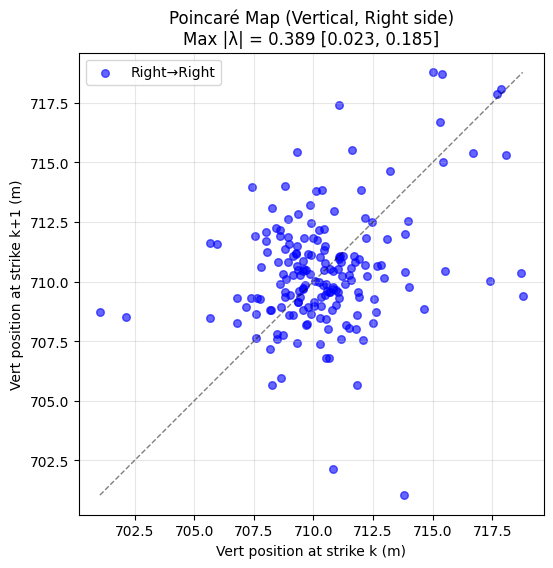


Analyzing Combined 6D state space...
Using Right-to-Right strides: 178 strides


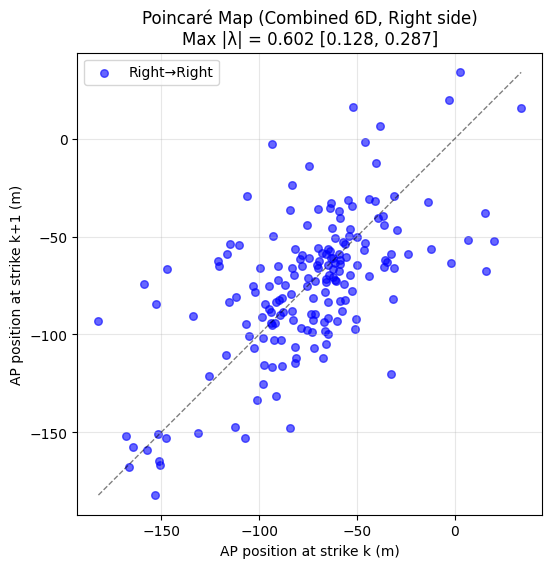


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.1709 [0.0203, 0.1782]
Anterior-posterior (y): λ = 0.5450 [0.0343, 0.1902]
Vertical (z):           λ = 0.3894 [0.0225, 0.1851]
Combined (6D):          λ = 0.6023 [0.1277, 0.2869]

Most stable direction:  Medio-lateral (λ = 0.1709)
Least stable direction: Anterior-posterior (λ = 0.5450)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 178 strides


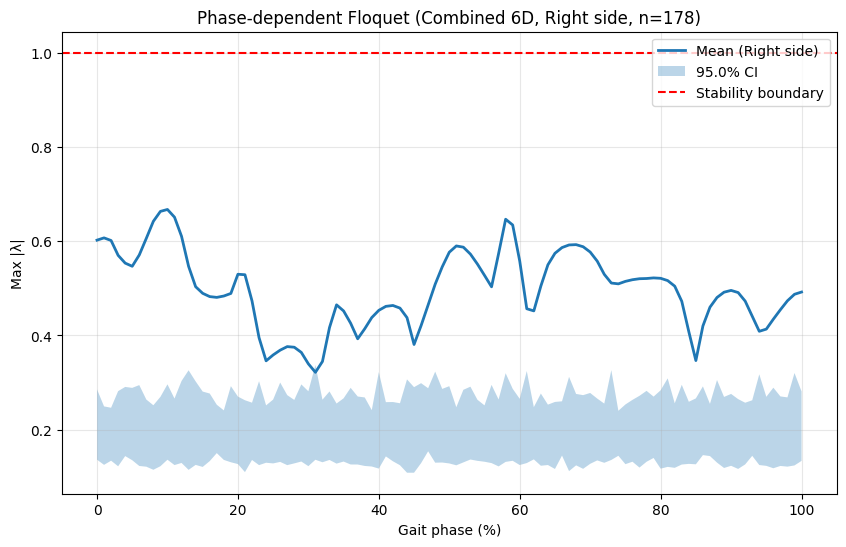

Most stable phase: 31% of gait cycle (λ = 0.3218)
Least stable phase: 10% of gait cycle (λ = 0.6674)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 178 strides


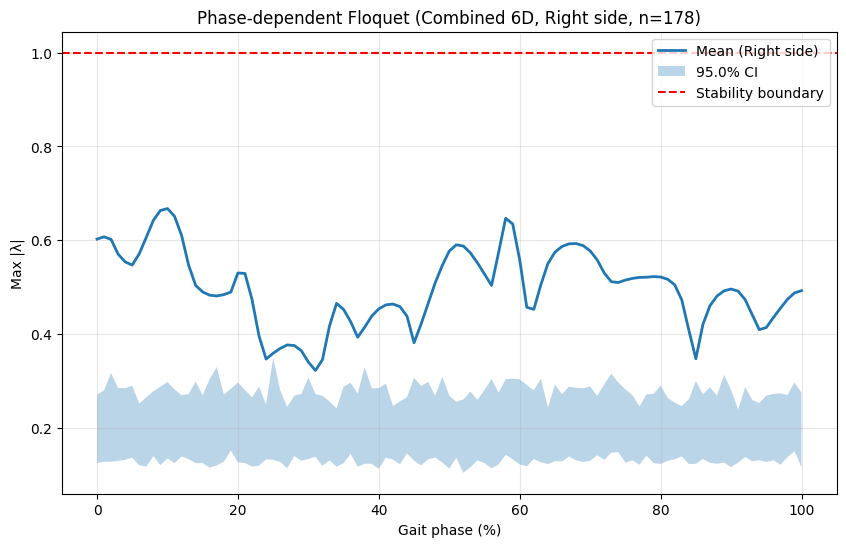

Most stable phase: 31% of gait cycle (λ = 0.3218)
Least stable phase: 10% of gait cycle (λ = 0.6674)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 178 strides


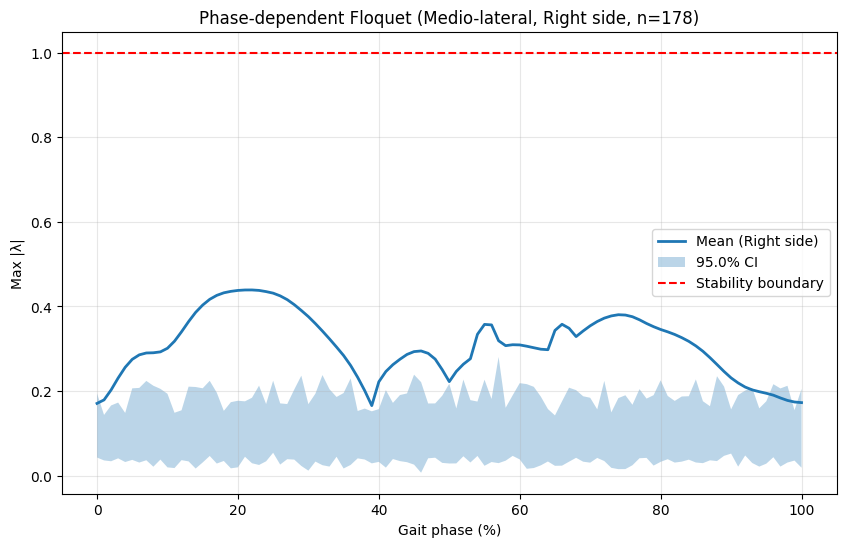

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 178 strides


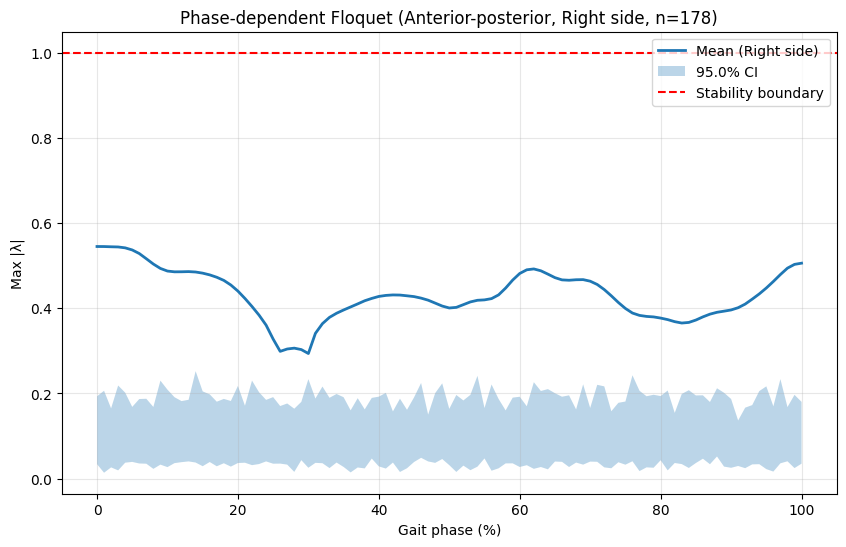

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 178 strides


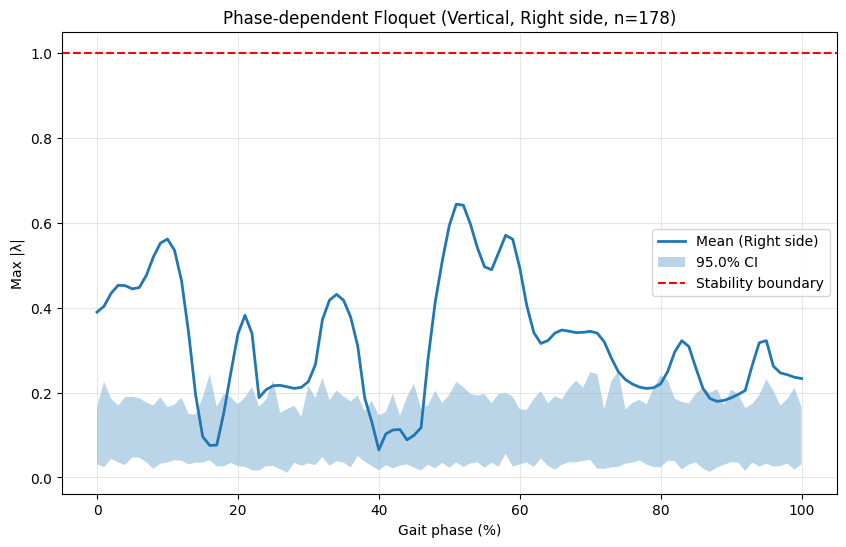

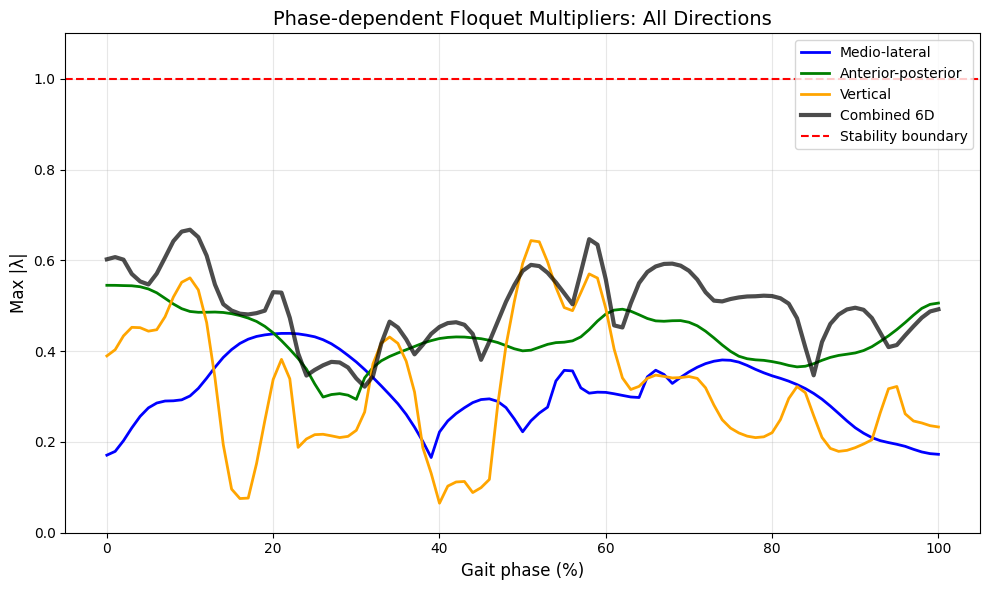


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.6023
Loading response (10%): λ = 0.6674
Mid-stance (30%): λ = 0.3397
Terminal stance (50%): λ = 0.5766
Pre-swing (60%): λ = 0.5579
Initial swing (73%): λ = 0.5112
Mid-swing (87%): λ = 0.4600
Terminal swing (100%): λ = 0.4921

Extracting normalized trajectories for limit cycle analysis...

Extracting 178 Right-to-Right strides
Extracted data shape: 178 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


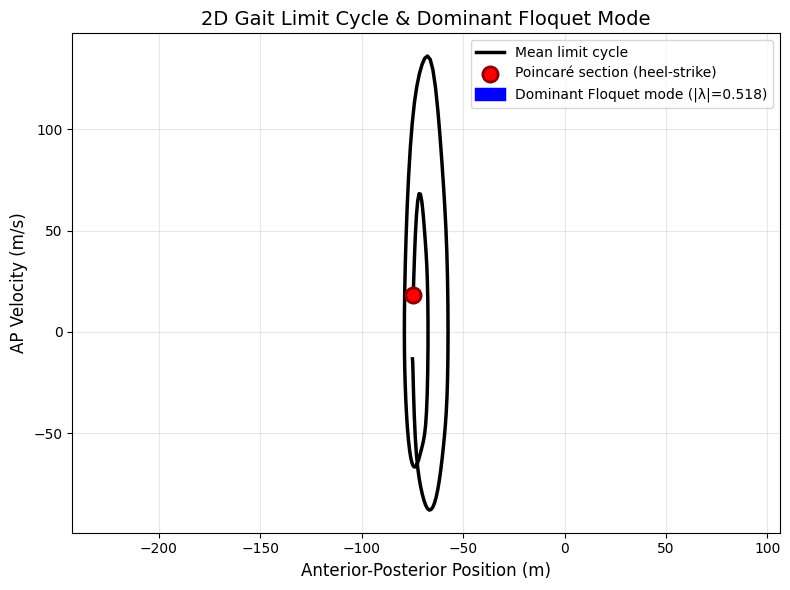


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.5181
- Eigenvector direction in (y, ẏ): [0.082, -0.058]
- Mean stride length: 21.529 m
- Peak forward velocity: 136.011 m/s


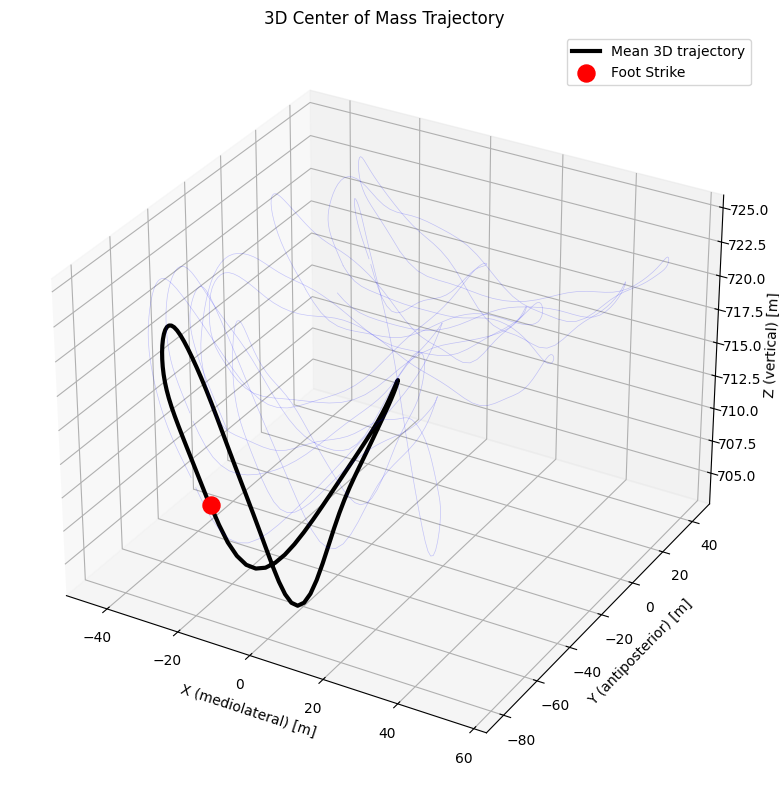

In [13]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "Pre.3" / "markers.nc"
    events_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "Pre"   / "Cereneo_SR_13_Fam_pre.4_events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

## Post

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.20s to 271.81s (all 171 R_FS)
Using 340 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 170 strides


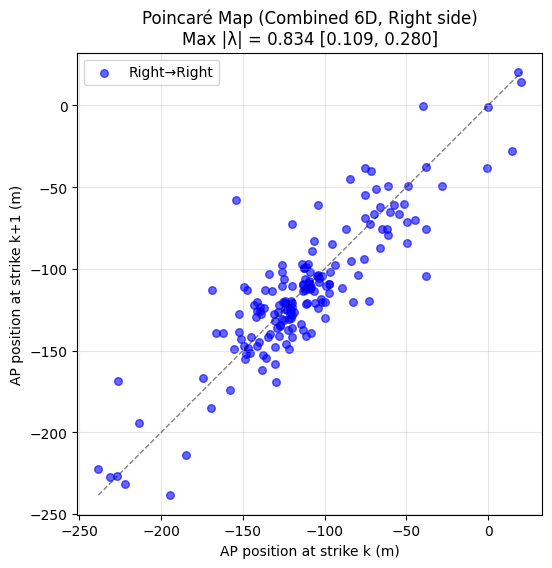


Combined (6D): λ = 0.8340 [0.1093, 0.2797]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 170 strides


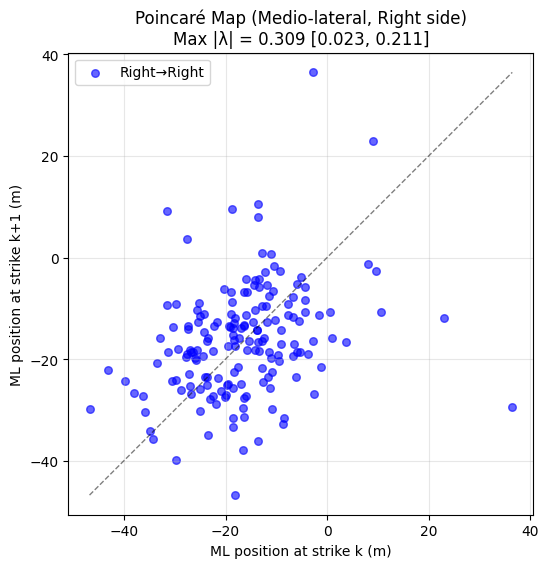


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 170 strides


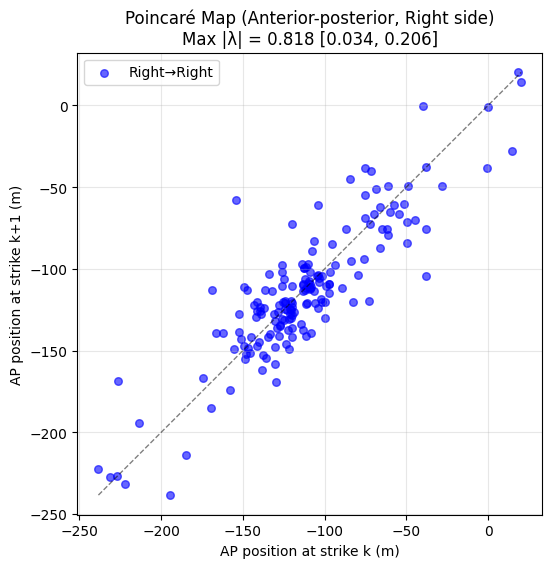


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 170 strides


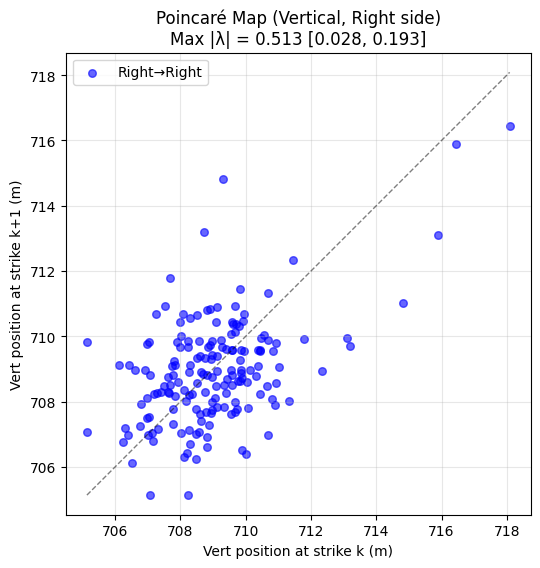


Analyzing Combined 6D state space...
Using Right-to-Right strides: 170 strides


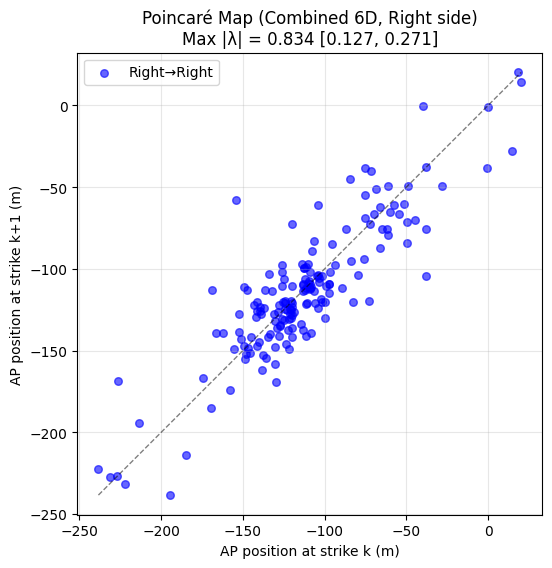


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.3093 [0.0228, 0.2113]
Anterior-posterior (y): λ = 0.8184 [0.0337, 0.2057]
Vertical (z):           λ = 0.5129 [0.0280, 0.1929]
Combined (6D):          λ = 0.8340 [0.1266, 0.2712]

Most stable direction:  Medio-lateral (λ = 0.3093)
Least stable direction: Anterior-posterior (λ = 0.8184)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 170 strides


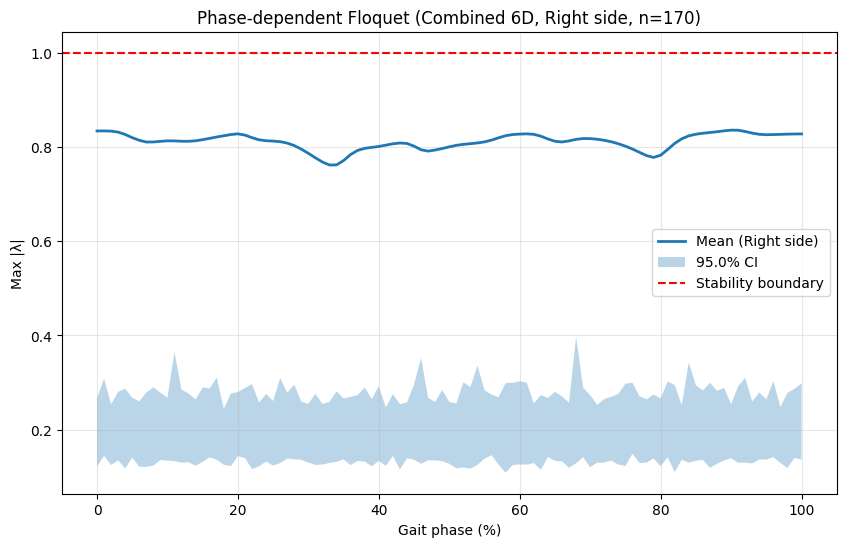

Most stable phase: 33% of gait cycle (λ = 0.7617)
Least stable phase: 90% of gait cycle (λ = 0.8357)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 170 strides


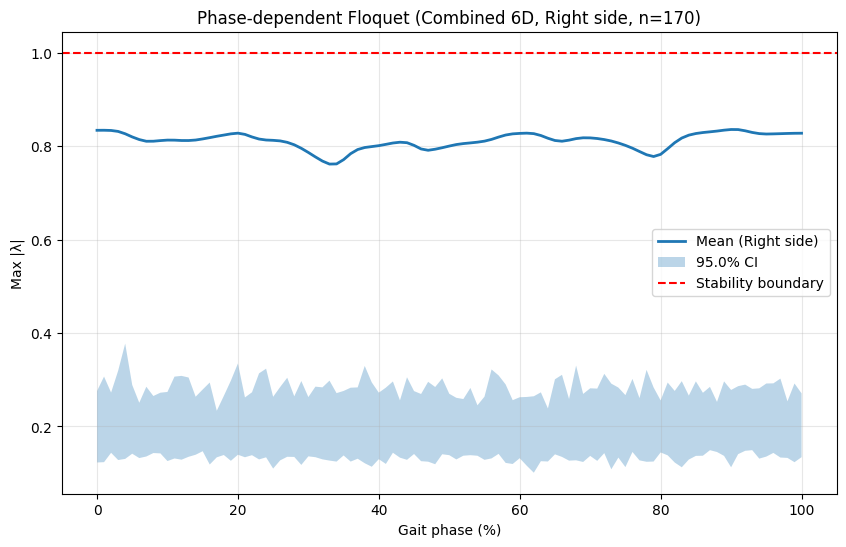

Most stable phase: 33% of gait cycle (λ = 0.7617)
Least stable phase: 90% of gait cycle (λ = 0.8357)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 170 strides


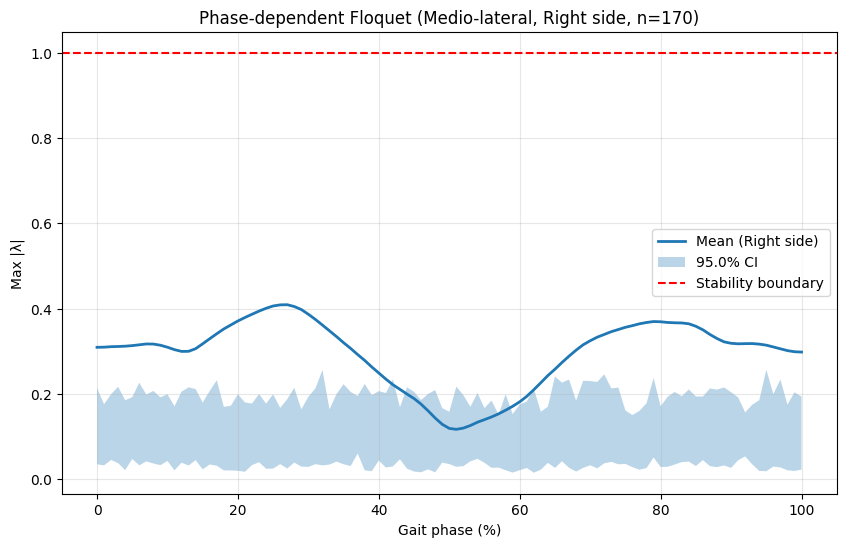

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 170 strides


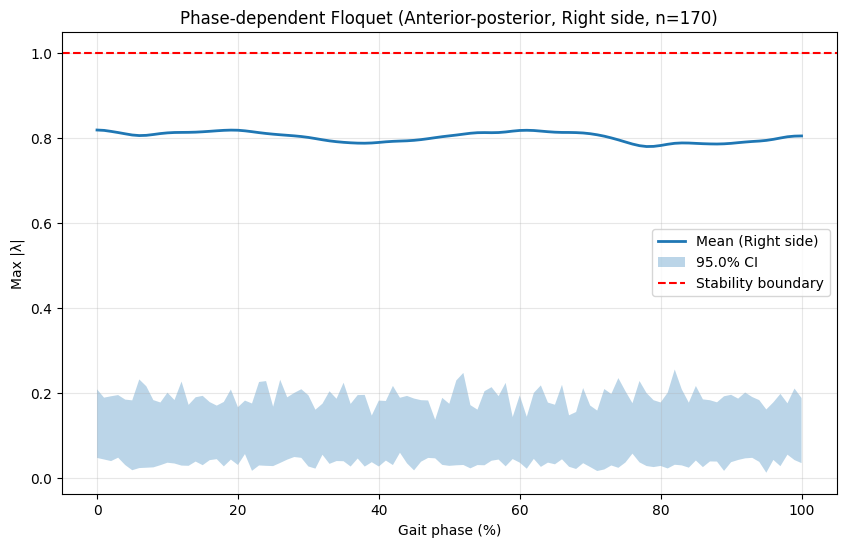

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 170 strides


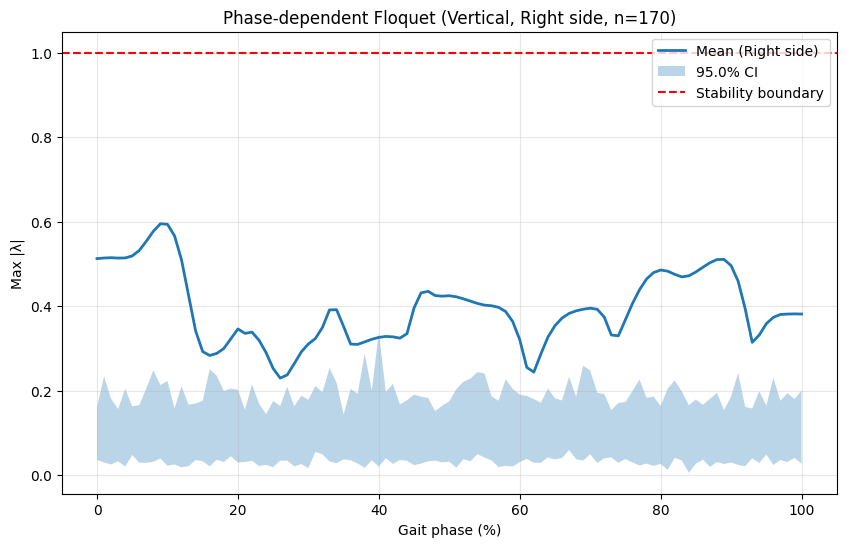

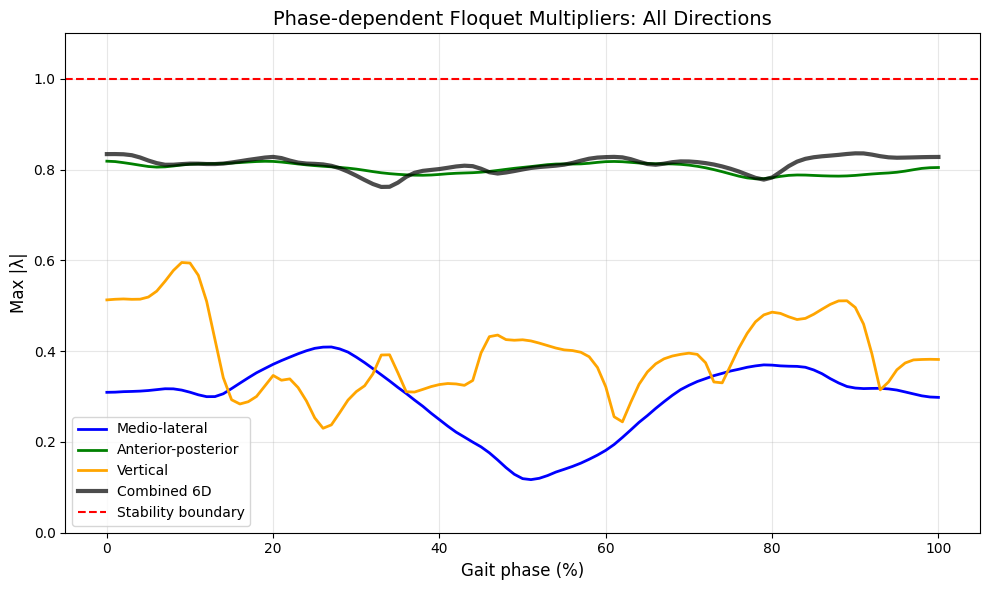


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.8340
Loading response (10%): λ = 0.8130
Mid-stance (30%): λ = 0.7865
Terminal stance (50%): λ = 0.8002
Pre-swing (60%): λ = 0.8273
Initial swing (73%): λ = 0.8111
Mid-swing (87%): λ = 0.8307
Terminal swing (100%): λ = 0.8277

Extracting normalized trajectories for limit cycle analysis...

Extracting 170 Right-to-Right strides
Extracted data shape: 170 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


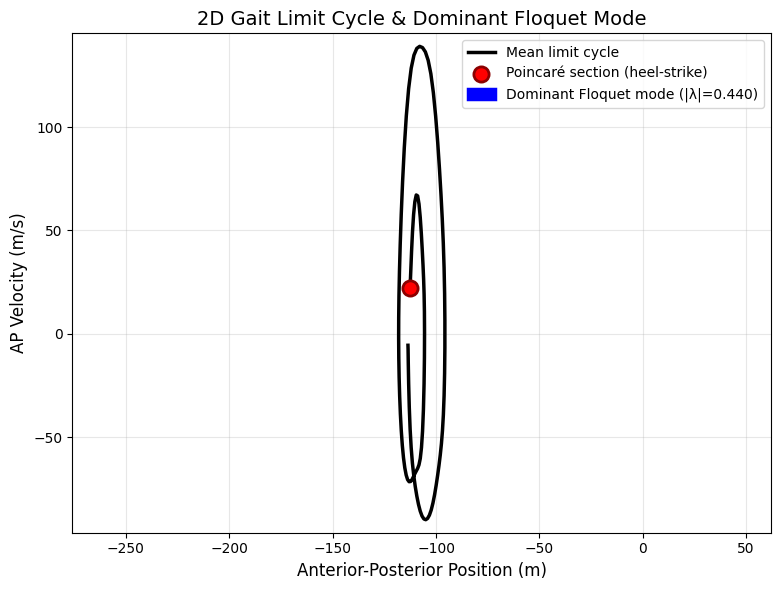


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.4396
- Eigenvector direction in (y, ẏ): [0.035, -0.094]
- Mean stride length: 22.369 m
- Peak forward velocity: 139.012 m/s


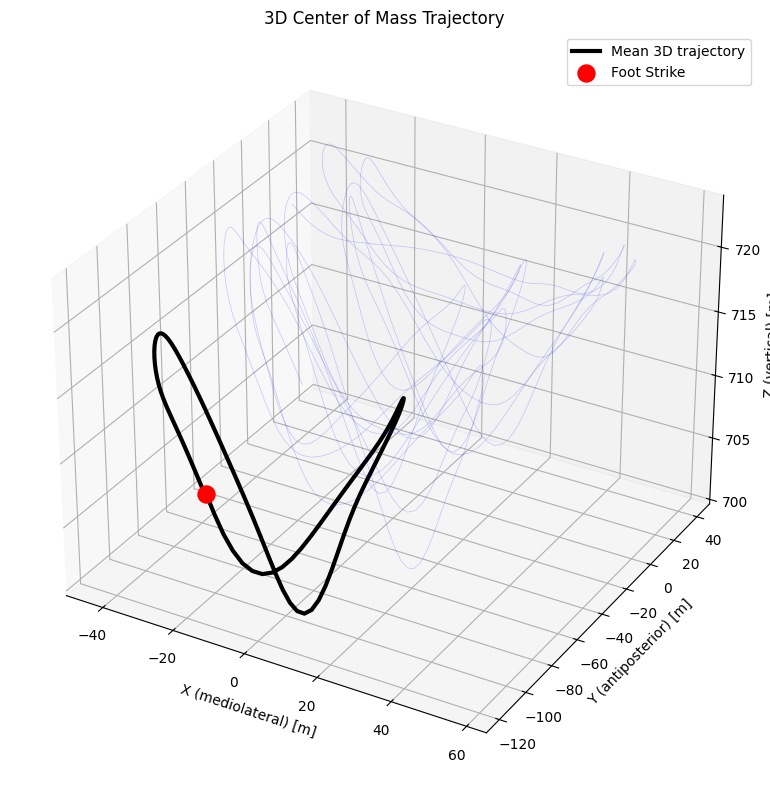

In [14]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "Post.3" / "markers.nc"
    events_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "Post"   / "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

# Patient 14

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.69s to 255.35s (first 201 R_FS)
Using 401 foot‐strike events for Floquet segmentation

Running Floquet analysis with improved methodology...

Using Right-to-Right strides: 200 strides


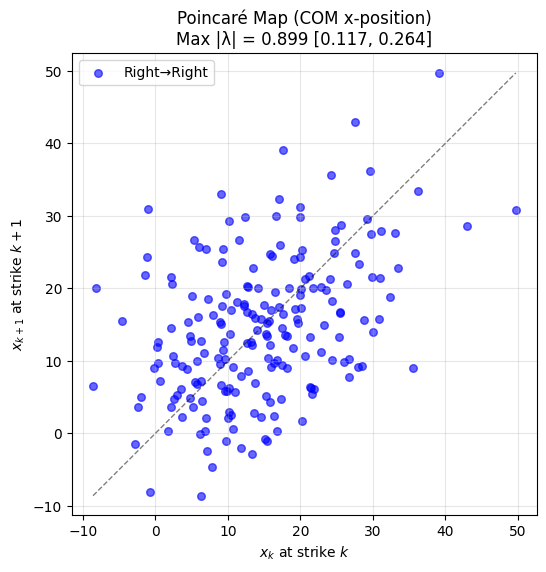


FLOQUET ANALYSIS RESULTS:
Max |Floquet λ| = 0.8995
95% Confidence Interval: [0.1170, 0.2645]
Number of cycles used: 200
Cycles trimmed from start/end: 0
Poincaré section type: Right

Running phase-dependent Floquet analysis...
Using Right-to-Right strides: 200 strides


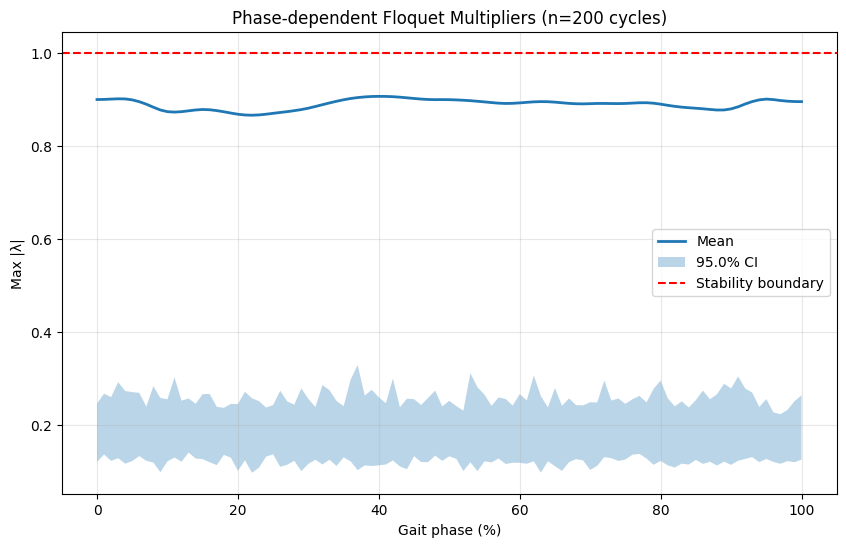


Most stable phase: 22% of gait cycle (λ = 0.8658)
Least stable phase: 40% of gait cycle (λ = 0.9063)

Extracting normalized trajectories for limit cycle analysis...

Extracting 200 Right-to-Right strides
Extracted data shape: 200 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


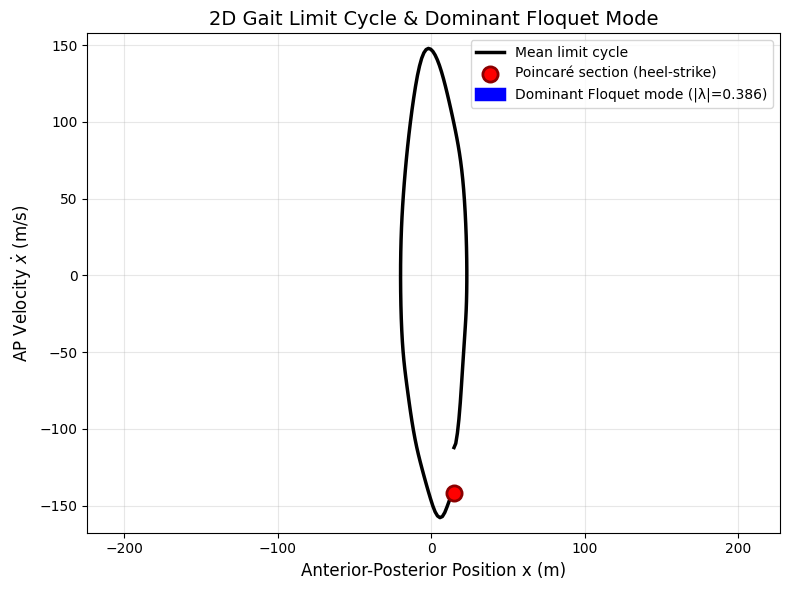


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.3861
- Eigenvector direction in (x, ẋ): [-0.087, 0.049]
- Mean stride length: 43.166 m
- Peak forward velocity: 147.810 m/s


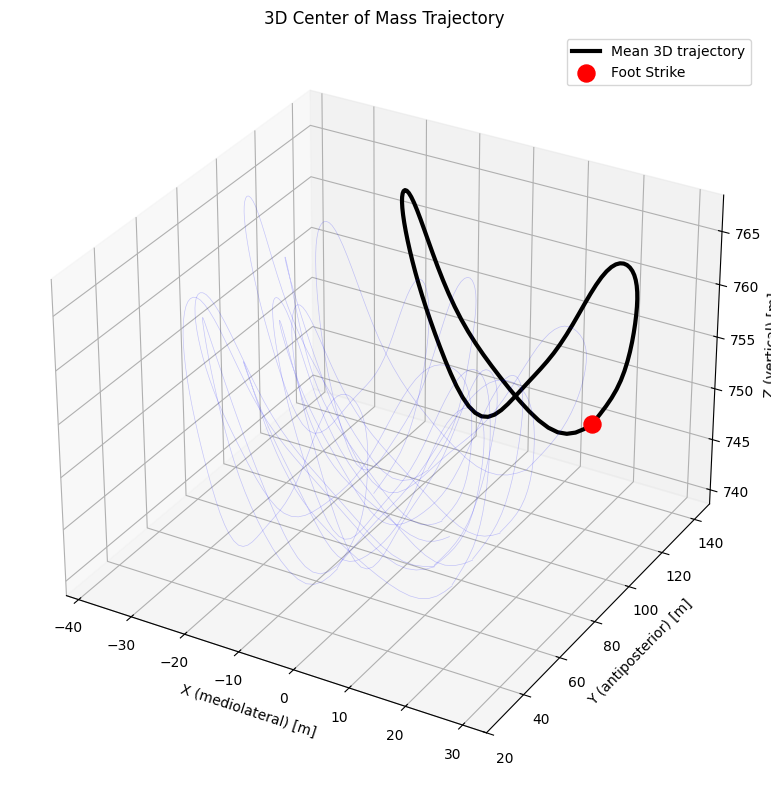

In [117]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events


def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # ——————————————————————————————
    # 1) Load the full continuous markers + events
    # ——————————————————————————————
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_14" / "Pre.3" / "markers.nc"
    events_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_14" / "Pre.4"   / "Cereneo_SR_14_Fam_pre.4_events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds       = xr.open_dataset(data_path)
    df_all   = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time    = SKIP_SAMPLES / fs

    # Get right foot strike events for windowing (you had Foot Strike here, which is correct)
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)
    if N_STRIDES < 150:
        raise ValueError(f"Need ≥{N_STRIDES} right FS, got {len(right_fs)}")

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (first {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 2) Run improved Floquet analysis with all recommendations
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running Floquet analysis with improved methodology...")
    print("="*60 + "\n")
    
    results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        # New parameters following recommendations:
        use_same_side=True,           # Recommendation 1: Use same-side Poincaré sections
        trim_cycles=0,                # Recommendation 4: Trim first/last 5 cycles
        bootstrap_n=100,              # Recommendation 2: Bootstrap for confidence intervals
        bootstrap_ci=95.0,            # 95% confidence interval
        lowpass_cutoff=8.0,          # Recommendation 3: 8 Hz low-pass filter
        min_cycles_required=150       # Recommendation 2: Require at least 150 cycles
    )
    
    # Display results
    print("\n" + "="*60)
    print("FLOQUET ANALYSIS RESULTS:")
    print("="*60)
    print(f"Max |Floquet λ| = {results['max_floquet']:.4f}")
    print(f"95% Confidence Interval: [{results['confidence_interval'][0]:.4f}, {results['confidence_interval'][1]:.4f}]")
    print(f"Number of cycles used: {results['n_cycles_used']}")
    print(f"Cycles trimmed from start/end: {results['trimmed_cycles']}")
    print(f"Poincaré section type: {results['side_used']}")
    print("="*60 + "\n")

    # ——————————————————————————————
    # 3) Additional analysis: Phase-dependent stability
    # ——————————————————————————————
    print("Running phase-dependent Floquet analysis...")
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,         # Enable phase-dependent analysis
        plot_spectrum=False,          # Don't plot spectrum for each phase
        use_same_side=True,
        trim_cycles=0,
        bootstrap_n=50,               # Fewer bootstrap iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    # Find the most/least stable phases
    max_floquet_phases = phase_results['max_floquet']
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)
    
    print(f"\nMost stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 4) Extract normalized data with same preprocessing as Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    # Extract data with same parameters as Floquet analysis
    # Note: You need to use the same trim_cycles value as in the Floquet analysis (0 in your case)
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,      # Same as Floquet analysis
        side_used=results['side_used'],  # Use the actual side from results
        trim_cycles=0,           # Match your Floquet analysis trimming
        lowpass_cutoff=8.0,      # Same filtering
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # ——————————————————————————————
    # 5) Plot the 2D limit cycle with dominant Floquet mode
    # ——————————————————————————————
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)
    
    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

# Patient 15

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.75s to 255.29s (first 225 R_FS)
Using 449 foot‐strike events for Floquet segmentation

Running Floquet analysis with improved methodology...

Using Right-to-Right strides: 224 strides


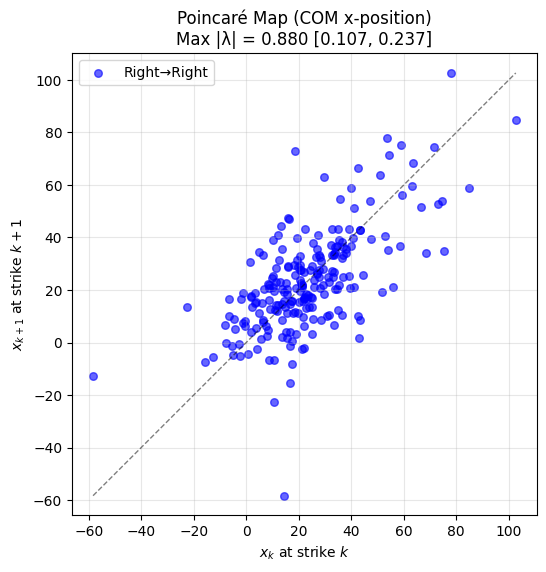


FLOQUET ANALYSIS RESULTS:
Max |Floquet λ| = 0.8802
95% Confidence Interval: [0.1066, 0.2374]
Number of cycles used: 224
Cycles trimmed from start/end: 0
Poincaré section type: Right

Running phase-dependent Floquet analysis...
Using Right-to-Right strides: 224 strides


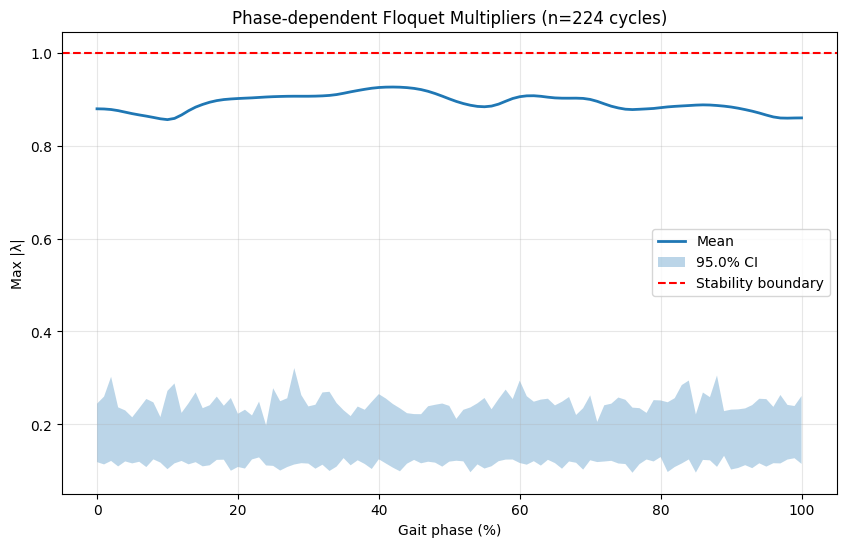


Most stable phase: 10% of gait cycle (λ = 0.8560)
Least stable phase: 42% of gait cycle (λ = 0.9262)

Extracting normalized trajectories for limit cycle analysis...

Extracting 224 Right-to-Right strides
Extracted data shape: 224 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


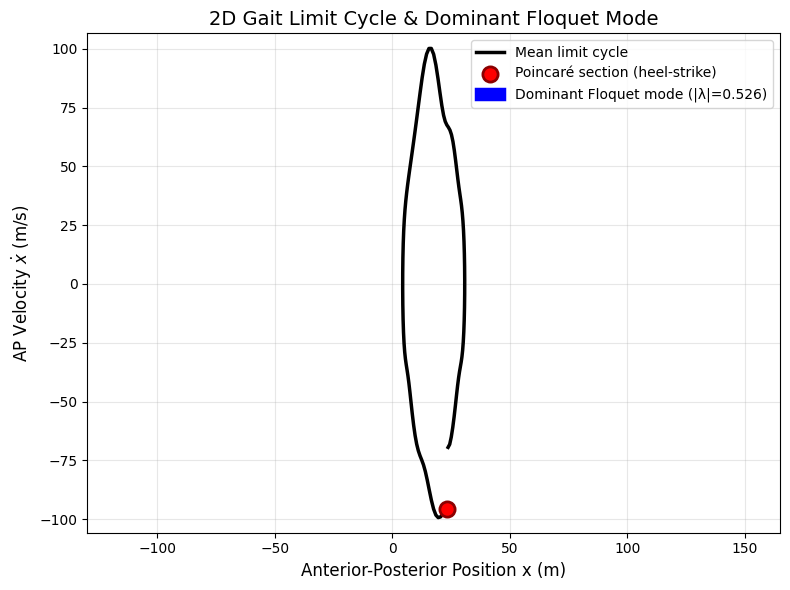


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.5265
- Eigenvector direction in (x, ẋ): [0.080, -0.059]
- Mean stride length: 26.390 m
- Peak forward velocity: 100.208 m/s


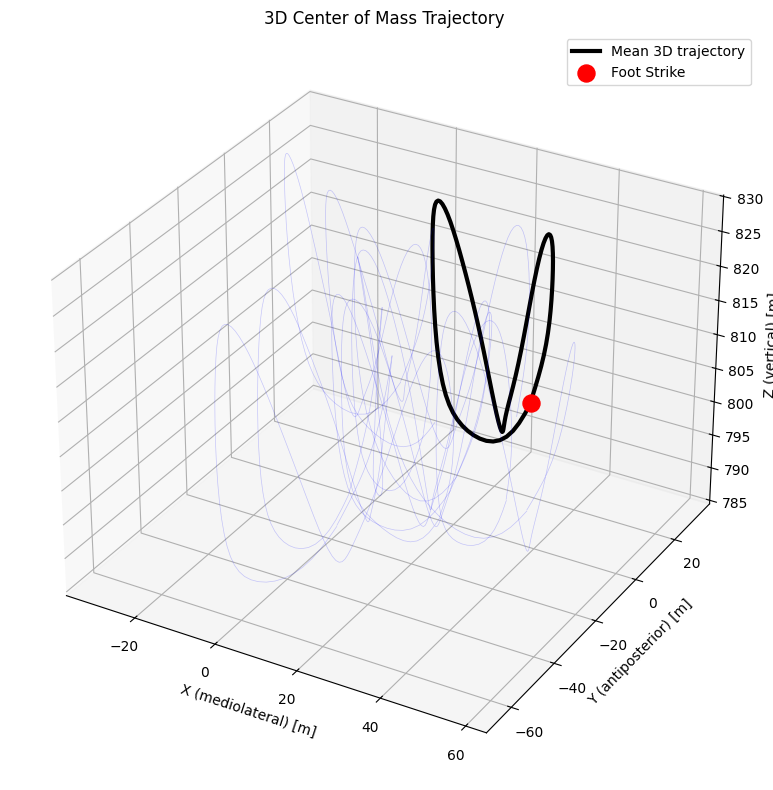

In [111]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events


def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # ——————————————————————————————
    # 1) Load the full continuous markers + events
    # ——————————————————————————————
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_15" / "Pre.3" / "markers.nc"
    events_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_15" / "Pre.4"   / "Cereneo_SR_15_Fam_pre.4_events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds       = xr.open_dataset(data_path)
    df_all   = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time    = SKIP_SAMPLES / fs

    # Get right foot strike events for windowing (you had Foot Strike here, which is correct)
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)
    if N_STRIDES < 150:
        raise ValueError(f"Need ≥{N_STRIDES} right FS, got {len(right_fs)}")

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (first {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 2) Run improved Floquet analysis with all recommendations
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running Floquet analysis with improved methodology...")
    print("="*60 + "\n")
    
    results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        # New parameters following recommendations:
        use_same_side=True,           # Recommendation 1: Use same-side Poincaré sections
        trim_cycles=0,                # Recommendation 4: Trim first/last 5 cycles
        bootstrap_n=100,              # Recommendation 2: Bootstrap for confidence intervals
        bootstrap_ci=95.0,            # 95% confidence interval
        lowpass_cutoff=5.0,          # Recommendation 3: 8 Hz low-pass filter
        min_cycles_required=150       # Recommendation 2: Require at least 150 cycles
    )
    
    # Display results
    print("\n" + "="*60)
    print("FLOQUET ANALYSIS RESULTS:")
    print("="*60)
    print(f"Max |Floquet λ| = {results['max_floquet']:.4f}")
    print(f"95% Confidence Interval: [{results['confidence_interval'][0]:.4f}, {results['confidence_interval'][1]:.4f}]")
    print(f"Number of cycles used: {results['n_cycles_used']}")
    print(f"Cycles trimmed from start/end: {results['trimmed_cycles']}")
    print(f"Poincaré section type: {results['side_used']}")
    print("="*60 + "\n")

    # ——————————————————————————————
    # 3) Additional analysis: Phase-dependent stability
    # ——————————————————————————————
    print("Running phase-dependent Floquet analysis...")
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,         # Enable phase-dependent analysis
        plot_spectrum=False,          # Don't plot spectrum for each phase
        use_same_side=True,
        trim_cycles=0,
        bootstrap_n=50,               # Fewer bootstrap iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    # Find the most/least stable phases
    max_floquet_phases = phase_results['max_floquet']
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)
    
    print(f"\nMost stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 4) Extract normalized data with same preprocessing as Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    # Extract data with same parameters as Floquet analysis
    # Note: You need to use the same trim_cycles value as in the Floquet analysis (0 in your case)
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,      # Same as Floquet analysis
        side_used=results['side_used'],  # Use the actual side from results
        trim_cycles=0,           # Match your Floquet analysis trimming
        lowpass_cutoff=8.0,      # Same filtering
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # ——————————————————————————————
    # 5) Plot the 2D limit cycle with dominant Floquet mode
    # ——————————————————————————————
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)
    
    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

# Patient 16

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.05s to 252.83s (first 218 R_FS)
Using 435 foot‐strike events for Floquet segmentation

Running Floquet analysis with improved methodology...

Using Right-to-Right strides: 217 strides


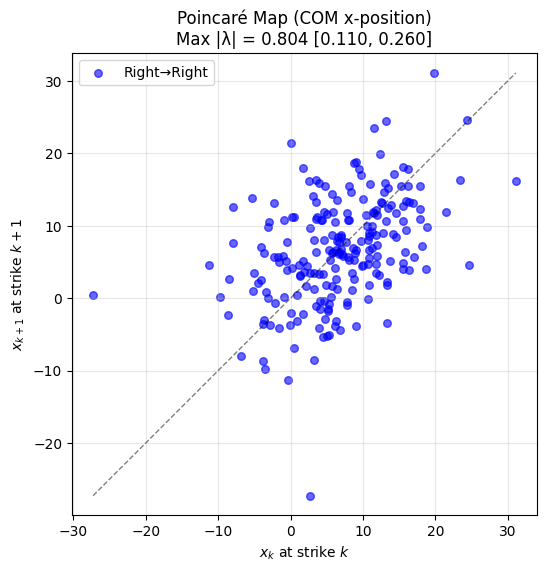


FLOQUET ANALYSIS RESULTS:
Max |Floquet λ| = 0.8043
95% Confidence Interval: [0.1104, 0.2600]
Number of cycles used: 217
Cycles trimmed from start/end: 0
Poincaré section type: Right

Running phase-dependent Floquet analysis...
Using Right-to-Right strides: 217 strides


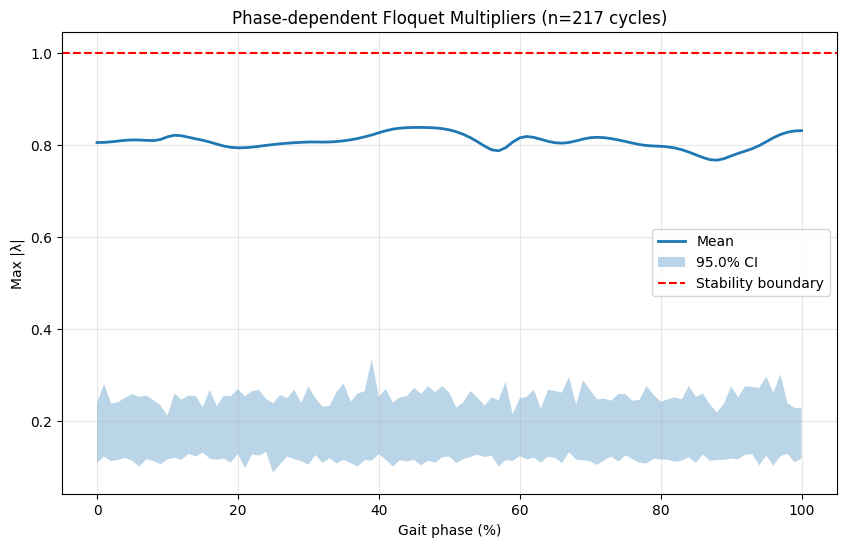


Most stable phase: 88% of gait cycle (λ = 0.7666)
Least stable phase: 46% of gait cycle (λ = 0.8377)

Extracting normalized trajectories for limit cycle analysis...

Extracting 217 Right-to-Right strides
Extracted data shape: 217 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


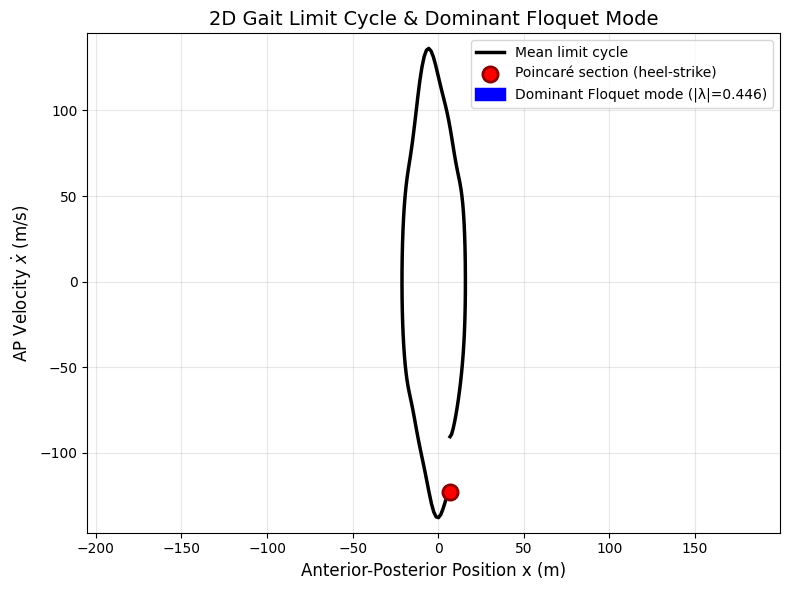


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.4464
- Eigenvector direction in (x, ẋ): [0.056, -0.083]
- Mean stride length: 37.046 m
- Peak forward velocity: 136.210 m/s


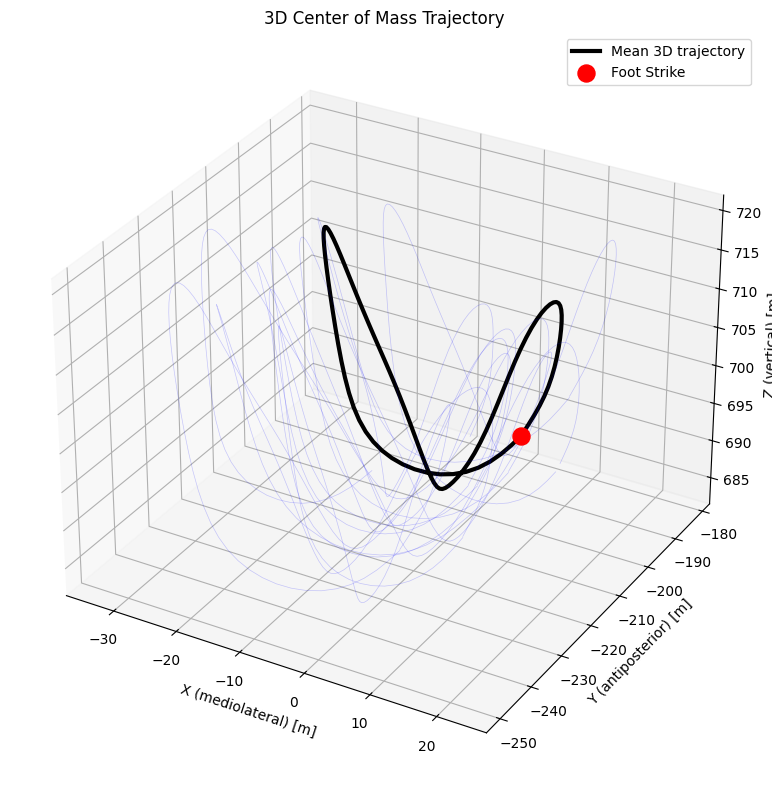

In [112]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events


def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # ——————————————————————————————
    # 1) Load the full continuous markers + events
    # ——————————————————————————————
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_16" / "Pre.3" / "markers.nc"
    events_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_16" / "Pre.4"   / "Cereneo_SR_16_Fam_pre.4_events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds       = xr.open_dataset(data_path)
    df_all   = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time    = SKIP_SAMPLES / fs

    # Get right foot strike events for windowing (you had Foot Strike here, which is correct)
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)
    if N_STRIDES < 150:
        raise ValueError(f"Need ≥{N_STRIDES} right FS, got {len(right_fs)}")

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (first {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 2) Run improved Floquet analysis with all recommendations
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running Floquet analysis with improved methodology...")
    print("="*60 + "\n")
    
    results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        # New parameters following recommendations:
        use_same_side=True,           # Recommendation 1: Use same-side Poincaré sections
        trim_cycles=0,                # Recommendation 4: Trim first/last 5 cycles
        bootstrap_n=100,              # Recommendation 2: Bootstrap for confidence intervals
        bootstrap_ci=95.0,            # 95% confidence interval
        lowpass_cutoff=5.0,          # Recommendation 3: 8 Hz low-pass filter
        min_cycles_required=150       # Recommendation 2: Require at least 150 cycles
    )
    
    # Display results
    print("\n" + "="*60)
    print("FLOQUET ANALYSIS RESULTS:")
    print("="*60)
    print(f"Max |Floquet λ| = {results['max_floquet']:.4f}")
    print(f"95% Confidence Interval: [{results['confidence_interval'][0]:.4f}, {results['confidence_interval'][1]:.4f}]")
    print(f"Number of cycles used: {results['n_cycles_used']}")
    print(f"Cycles trimmed from start/end: {results['trimmed_cycles']}")
    print(f"Poincaré section type: {results['side_used']}")
    print("="*60 + "\n")

    # ——————————————————————————————
    # 3) Additional analysis: Phase-dependent stability
    # ——————————————————————————————
    print("Running phase-dependent Floquet analysis...")
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,         # Enable phase-dependent analysis
        plot_spectrum=False,          # Don't plot spectrum for each phase
        use_same_side=True,
        trim_cycles=0,
        bootstrap_n=50,               # Fewer bootstrap iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    # Find the most/least stable phases
    max_floquet_phases = phase_results['max_floquet']
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)
    
    print(f"\nMost stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 4) Extract normalized data with same preprocessing as Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    # Extract data with same parameters as Floquet analysis
    # Note: You need to use the same trim_cycles value as in the Floquet analysis (0 in your case)
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,      # Same as Floquet analysis
        side_used=results['side_used'],  # Use the actual side from results
        trim_cycles=0,           # Match your Floquet analysis trimming
        lowpass_cutoff=8.0,      # Same filtering
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # ——————————————————————————————
    # 5) Plot the 2D limit cycle with dominant Floquet mode
    # ——————————————————————————————
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)
    
    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

# Patient 17

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 11.09s to 250.44s (first 216 R_FS)
Using 430 foot‐strike events for Floquet segmentation

Running Floquet analysis with improved methodology...

Using Right-to-Right strides: 215 strides


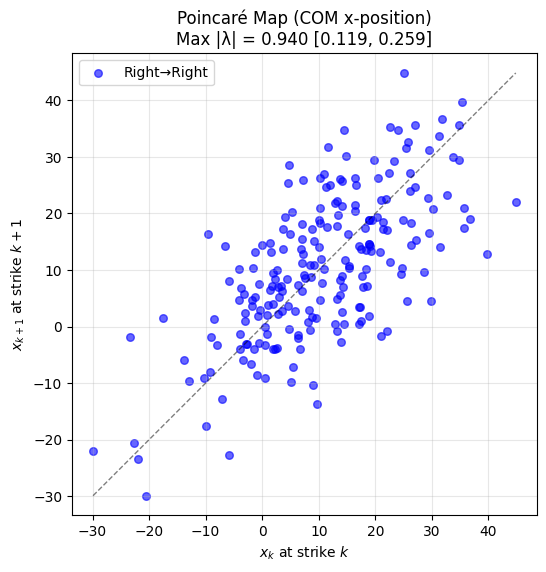


FLOQUET ANALYSIS RESULTS:
Max |Floquet λ| = 0.9402
95% Confidence Interval: [0.1186, 0.2588]
Number of cycles used: 215
Cycles trimmed from start/end: 0
Poincaré section type: Right

Running phase-dependent Floquet analysis...
Using Right-to-Right strides: 215 strides


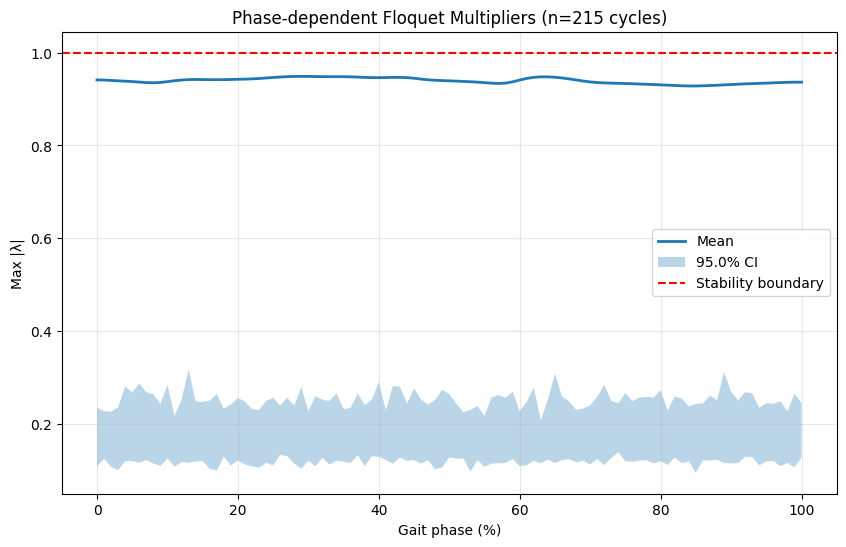


Most stable phase: 84% of gait cycle (λ = 0.9283)
Least stable phase: 29% of gait cycle (λ = 0.9490)

Extracting normalized trajectories for limit cycle analysis...

Extracting 215 Right-to-Right strides
Extracted data shape: 215 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


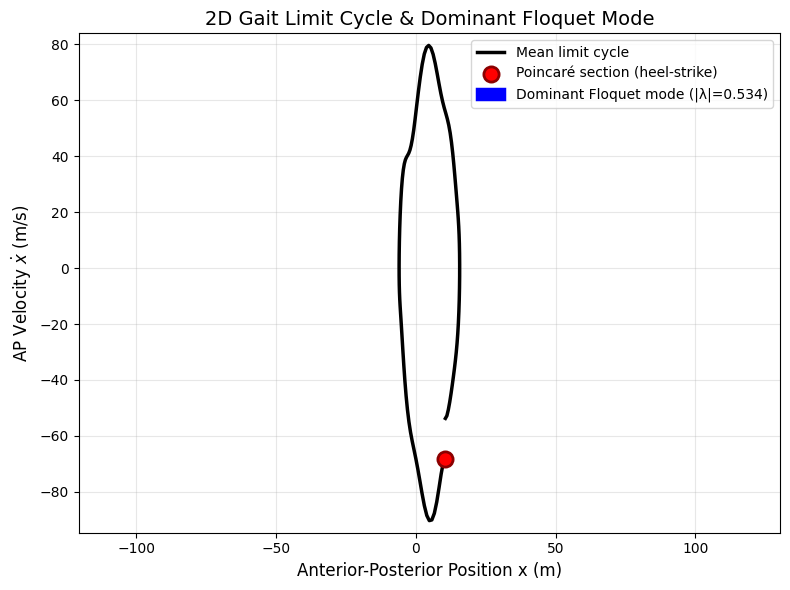


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.5343
- Eigenvector direction in (x, ẋ): [0.077, -0.064]
- Mean stride length: 21.658 m
- Peak forward velocity: 79.647 m/s


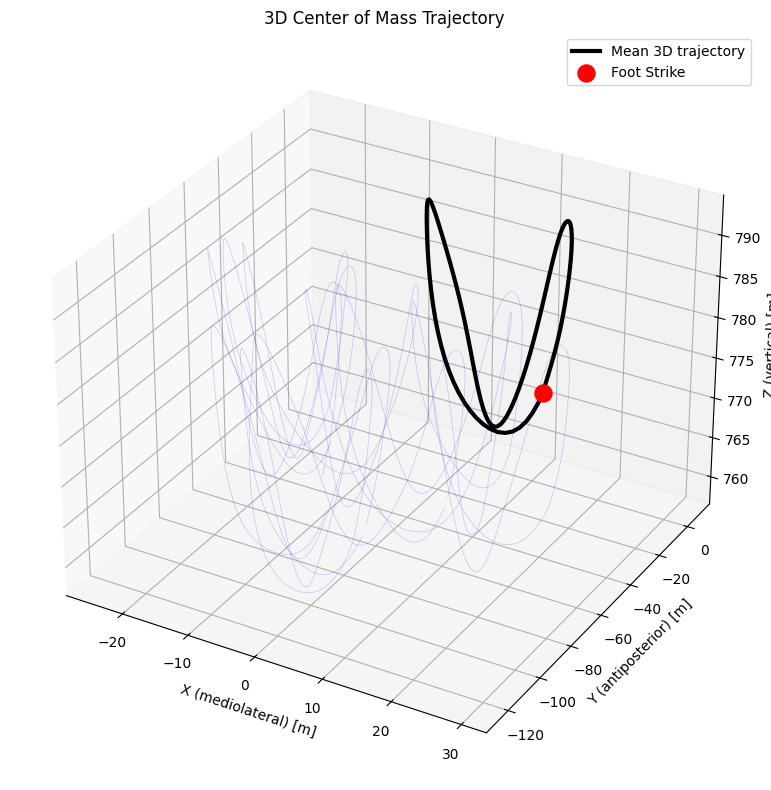

In [114]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events


def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # ——————————————————————————————
    # 1) Load the full continuous markers + events
    # ——————————————————————————————
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_17" / "Pre.3" / "markers.nc"
    events_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_17" / "Pre.4"   / "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds       = xr.open_dataset(data_path)
    df_all   = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time    = SKIP_SAMPLES / fs

    # Get right foot strike events for windowing (you had Foot Strike here, which is correct)
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)
    if N_STRIDES < 150:
        raise ValueError(f"Need ≥{N_STRIDES} right FS, got {len(right_fs)}")

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (first {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 2) Run improved Floquet analysis with all recommendations
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running Floquet analysis with improved methodology...")
    print("="*60 + "\n")
    
    results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        # New parameters following recommendations:
        use_same_side=True,           # Recommendation 1: Use same-side Poincaré sections
        trim_cycles=0,                # Recommendation 4: Trim first/last 5 cycles
        bootstrap_n=100,              # Recommendation 2: Bootstrap for confidence intervals
        bootstrap_ci=95.0,            # 95% confidence interval
        lowpass_cutoff=5.0,          # Recommendation 3: 8 Hz low-pass filter
        min_cycles_required=150       # Recommendation 2: Require at least 150 cycles
    )
    
    # Display results
    print("\n" + "="*60)
    print("FLOQUET ANALYSIS RESULTS:")
    print("="*60)
    print(f"Max |Floquet λ| = {results['max_floquet']:.4f}")
    print(f"95% Confidence Interval: [{results['confidence_interval'][0]:.4f}, {results['confidence_interval'][1]:.4f}]")
    print(f"Number of cycles used: {results['n_cycles_used']}")
    print(f"Cycles trimmed from start/end: {results['trimmed_cycles']}")
    print(f"Poincaré section type: {results['side_used']}")
    print("="*60 + "\n")

    # ——————————————————————————————
    # 3) Additional analysis: Phase-dependent stability
    # ——————————————————————————————
    print("Running phase-dependent Floquet analysis...")
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,         # Enable phase-dependent analysis
        plot_spectrum=False,          # Don't plot spectrum for each phase
        use_same_side=True,
        trim_cycles=0,
        bootstrap_n=50,               # Fewer bootstrap iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    # Find the most/least stable phases
    max_floquet_phases = phase_results['max_floquet']
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)
    
    print(f"\nMost stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 4) Extract normalized data with same preprocessing as Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    # Extract data with same parameters as Floquet analysis
    # Note: You need to use the same trim_cycles value as in the Floquet analysis (0 in your case)
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,      # Same as Floquet analysis
        side_used=results['side_used'],  # Use the actual side from results
        trim_cycles=0,           # Match your Floquet analysis trimming
        lowpass_cutoff=8.0,      # Same filtering
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # ——————————————————————————————
    # 5) Plot the 2D limit cycle with dominant Floquet mode
    # ——————————————————————————————
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)
    
    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

# Patient 18

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.13s to 246.57s (first 229 R_FS)
Using 456 foot‐strike events for Floquet segmentation

Running Floquet analysis with improved methodology...

Using Right-to-Right strides: 228 strides


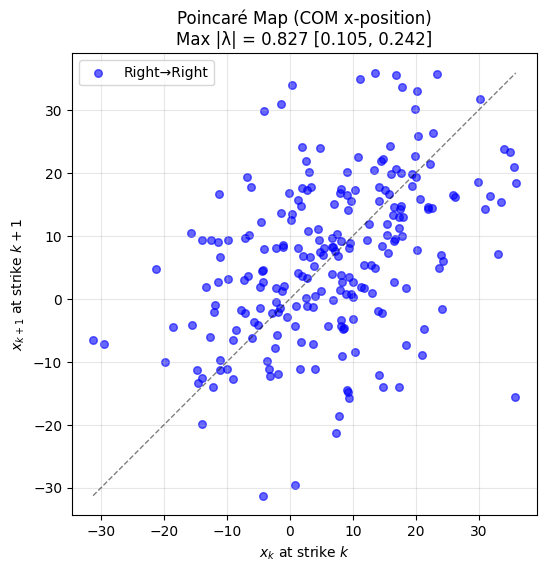


FLOQUET ANALYSIS RESULTS:
Max |Floquet λ| = 0.8273
95% Confidence Interval: [0.1055, 0.2425]
Number of cycles used: 228
Cycles trimmed from start/end: 0
Poincaré section type: Right

Running phase-dependent Floquet analysis...
Using Right-to-Right strides: 228 strides


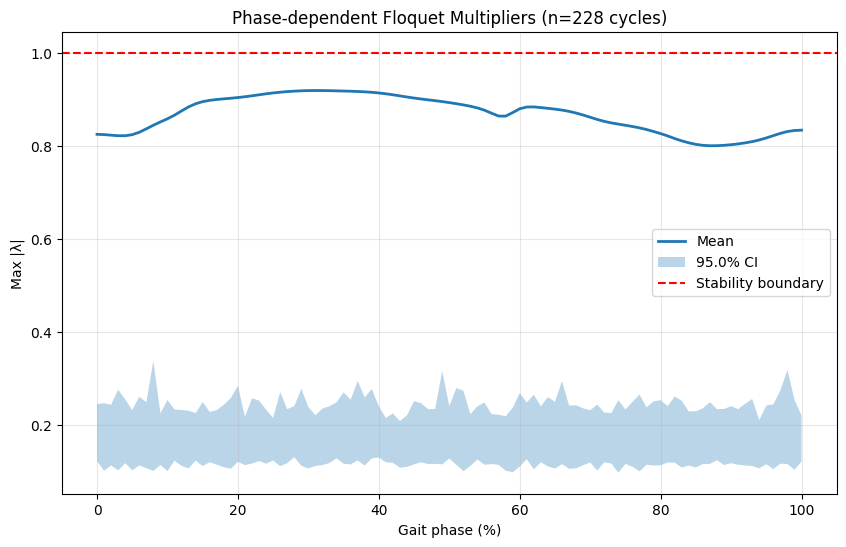


Most stable phase: 87% of gait cycle (λ = 0.8001)
Least stable phase: 31% of gait cycle (λ = 0.9188)

Extracting normalized trajectories for limit cycle analysis...

Extracting 228 Right-to-Right strides
Extracted data shape: 228 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


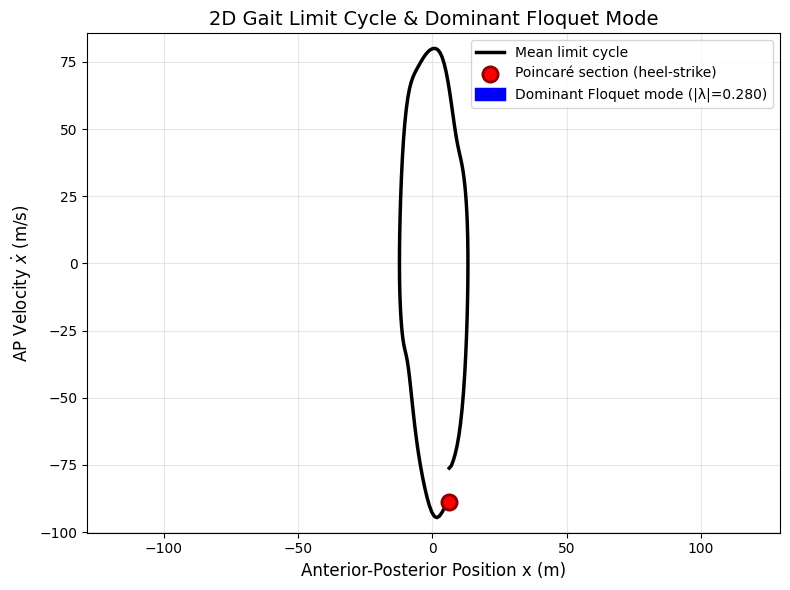


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.2805
- Eigenvector direction in (x, ẋ): [0.090, -0.044]
- Mean stride length: 25.490 m
- Peak forward velocity: 80.020 m/s


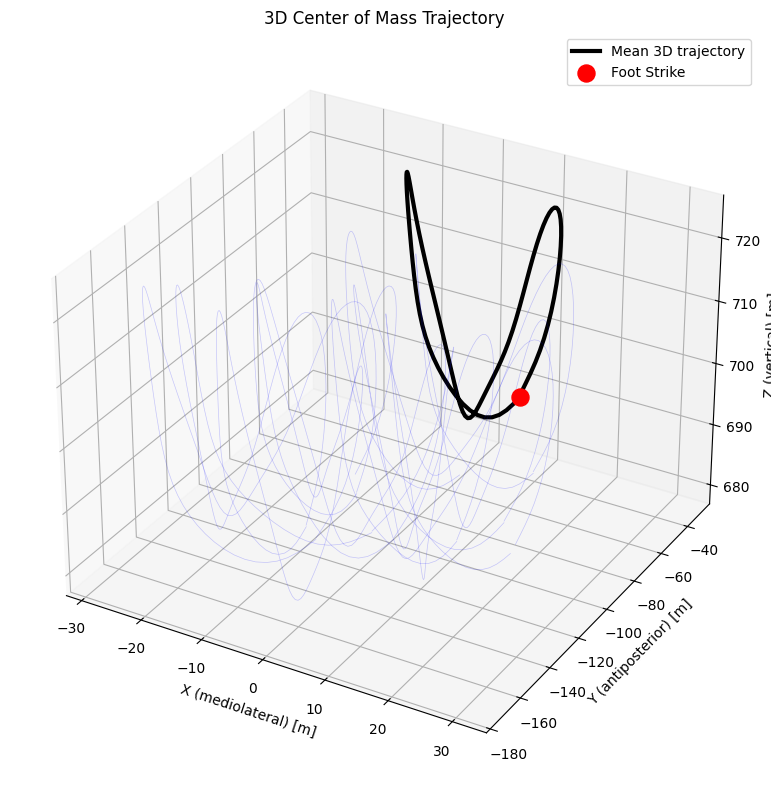

In [115]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events


def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # ——————————————————————————————
    # 1) Load the full continuous markers + events
    # ——————————————————————————————
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_18" / "Pre.3" / "markers.nc"
    events_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_18" / "Pre.4"   / "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds       = xr.open_dataset(data_path)
    df_all   = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time    = SKIP_SAMPLES / fs

    # Get right foot strike events for windowing (you had Foot Strike here, which is correct)
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)
    if N_STRIDES < 150:
        raise ValueError(f"Need ≥{N_STRIDES} right FS, got {len(right_fs)}")

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (first {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 2) Run improved Floquet analysis with all recommendations
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running Floquet analysis with improved methodology...")
    print("="*60 + "\n")
    
    results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        # New parameters following recommendations:
        use_same_side=True,           # Recommendation 1: Use same-side Poincaré sections
        trim_cycles=0,                # Recommendation 4: Trim first/last 5 cycles
        bootstrap_n=100,              # Recommendation 2: Bootstrap for confidence intervals
        bootstrap_ci=95.0,            # 95% confidence interval
        lowpass_cutoff=5.0,          # Recommendation 3: 8 Hz low-pass filter
        min_cycles_required=150       # Recommendation 2: Require at least 150 cycles
    )
    
    # Display results
    print("\n" + "="*60)
    print("FLOQUET ANALYSIS RESULTS:")
    print("="*60)
    print(f"Max |Floquet λ| = {results['max_floquet']:.4f}")
    print(f"95% Confidence Interval: [{results['confidence_interval'][0]:.4f}, {results['confidence_interval'][1]:.4f}]")
    print(f"Number of cycles used: {results['n_cycles_used']}")
    print(f"Cycles trimmed from start/end: {results['trimmed_cycles']}")
    print(f"Poincaré section type: {results['side_used']}")
    print("="*60 + "\n")

    # ——————————————————————————————
    # 3) Additional analysis: Phase-dependent stability
    # ——————————————————————————————
    print("Running phase-dependent Floquet analysis...")
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,         # Enable phase-dependent analysis
        plot_spectrum=False,          # Don't plot spectrum for each phase
        use_same_side=True,
        trim_cycles=0,
        bootstrap_n=50,               # Fewer bootstrap iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    # Find the most/least stable phases
    max_floquet_phases = phase_results['max_floquet']
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)
    
    print(f"\nMost stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 4) Extract normalized data with same preprocessing as Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    # Extract data with same parameters as Floquet analysis
    # Note: You need to use the same trim_cycles value as in the Floquet analysis (0 in your case)
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,      # Same as Floquet analysis
        side_used=results['side_used'],  # Use the actual side from results
        trim_cycles=0,           # Match your Floquet analysis trimming
        lowpass_cutoff=8.0,      # Same filtering
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # ——————————————————————————————
    # 5) Plot the 2D limit cycle with dominant Floquet mode
    # ——————————————————————————————
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)
    
    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

# Patient 19

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 11.06s to 249.98s (first 227 R_FS)
Using 452 foot‐strike events for Floquet segmentation

Running Floquet analysis with improved methodology...

Using Right-to-Right strides: 226 strides


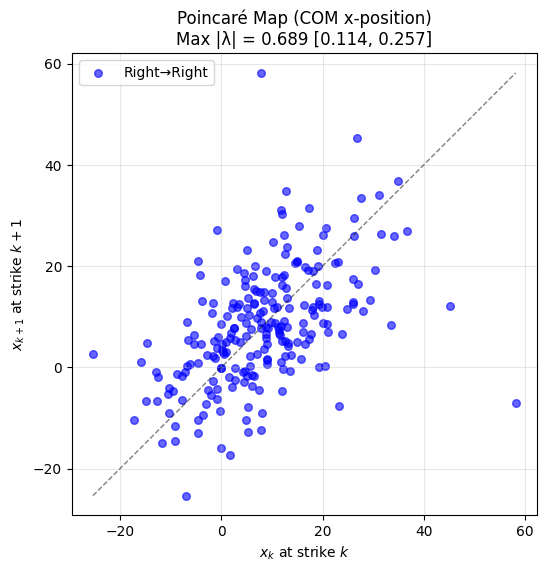


FLOQUET ANALYSIS RESULTS:
Max |Floquet λ| = 0.6895
95% Confidence Interval: [0.1141, 0.2573]
Number of cycles used: 226
Cycles trimmed from start/end: 0
Poincaré section type: Right

Running phase-dependent Floquet analysis...
Using Right-to-Right strides: 226 strides


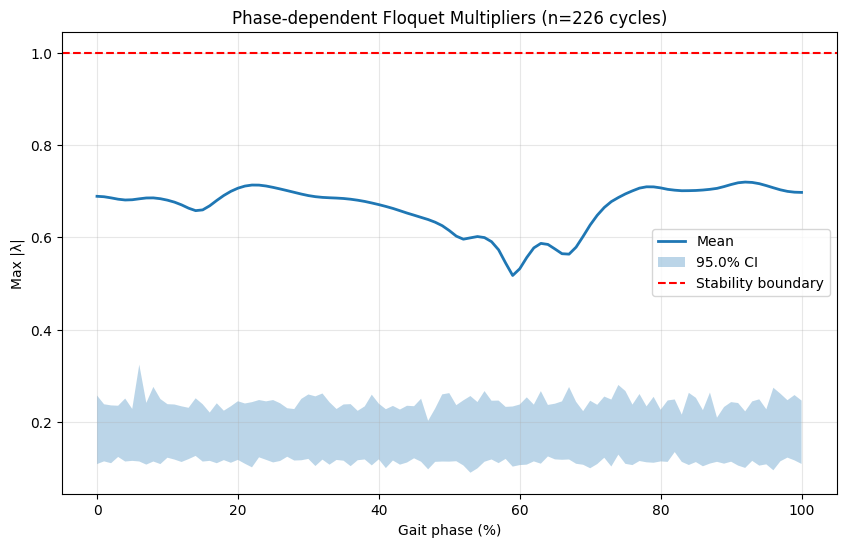


Most stable phase: 59% of gait cycle (λ = 0.5174)
Least stable phase: 92% of gait cycle (λ = 0.7197)

Extracting normalized trajectories for limit cycle analysis...

Extracting 226 Right-to-Right strides
Extracted data shape: 226 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


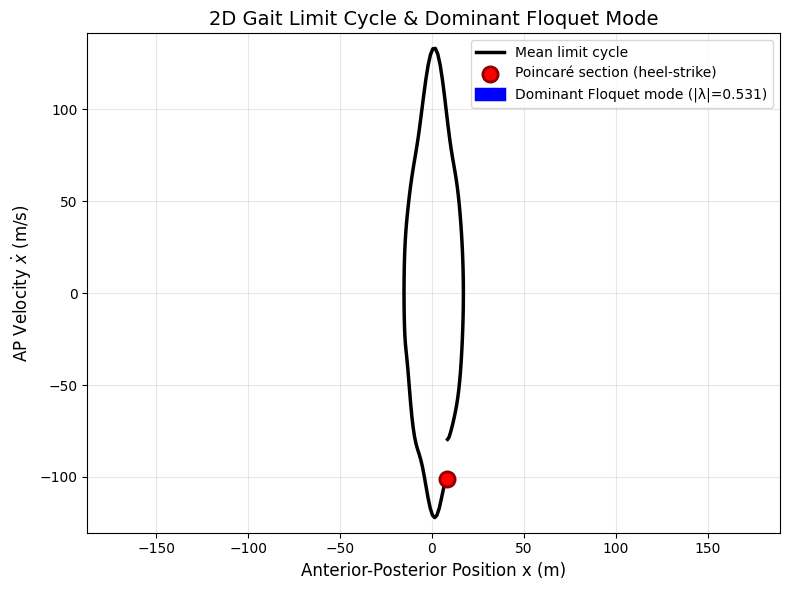


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.5311
- Eigenvector direction in (x, ẋ): [0.079, -0.061]
- Mean stride length: 32.289 m
- Peak forward velocity: 133.099 m/s


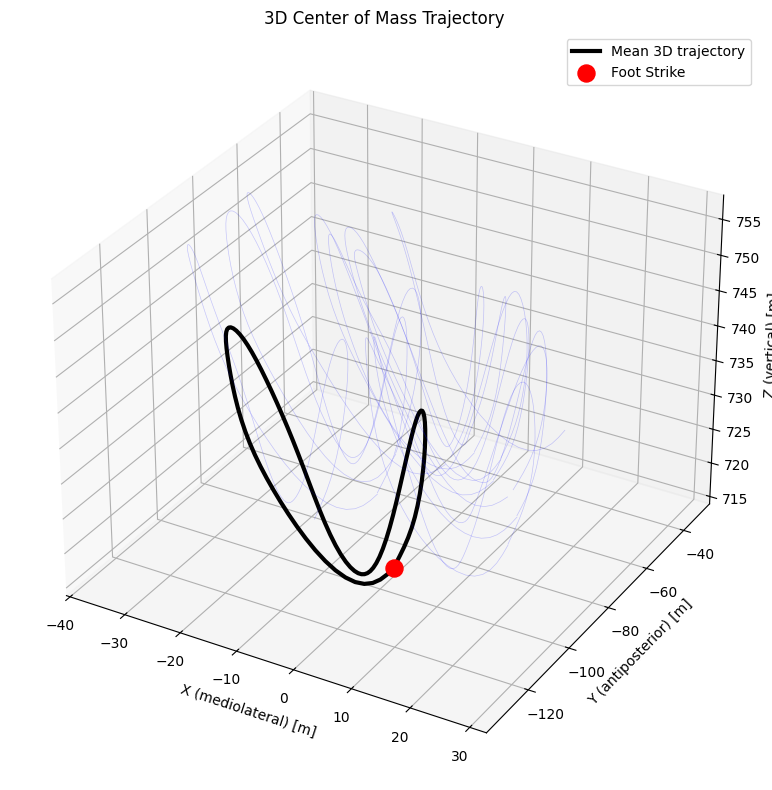

In [116]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events


def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # ——————————————————————————————
    # 1) Load the full continuous markers + events
    # ——————————————————————————————
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_19" / "Pre.3" / "markers.nc"
    events_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_19" / "Pre.4"   / "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds       = xr.open_dataset(data_path)
    df_all   = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time    = SKIP_SAMPLES / fs

    # Get right foot strike events for windowing (you had Foot Strike here, which is correct)
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)
    if N_STRIDES < 150:
        raise ValueError(f"Need ≥{N_STRIDES} right FS, got {len(right_fs)}")

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (first {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 2) Run improved Floquet analysis with all recommendations
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running Floquet analysis with improved methodology...")
    print("="*60 + "\n")
    
    results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        # New parameters following recommendations:
        use_same_side=True,           # Recommendation 1: Use same-side Poincaré sections
        trim_cycles=0,                # Recommendation 4: Trim first/last 5 cycles
        bootstrap_n=100,              # Recommendation 2: Bootstrap for confidence intervals
        bootstrap_ci=95.0,            # 95% confidence interval
        lowpass_cutoff=5.0,          # Recommendation 3: 8 Hz low-pass filter
        min_cycles_required=150       # Recommendation 2: Require at least 150 cycles
    )
    
    # Display results
    print("\n" + "="*60)
    print("FLOQUET ANALYSIS RESULTS:")
    print("="*60)
    print(f"Max |Floquet λ| = {results['max_floquet']:.4f}")
    print(f"95% Confidence Interval: [{results['confidence_interval'][0]:.4f}, {results['confidence_interval'][1]:.4f}]")
    print(f"Number of cycles used: {results['n_cycles_used']}")
    print(f"Cycles trimmed from start/end: {results['trimmed_cycles']}")
    print(f"Poincaré section type: {results['side_used']}")
    print("="*60 + "\n")

    # ——————————————————————————————
    # 3) Additional analysis: Phase-dependent stability
    # ——————————————————————————————
    print("Running phase-dependent Floquet analysis...")
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,         # Enable phase-dependent analysis
        plot_spectrum=False,          # Don't plot spectrum for each phase
        use_same_side=True,
        trim_cycles=0,
        bootstrap_n=50,               # Fewer bootstrap iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    # Find the most/least stable phases
    max_floquet_phases = phase_results['max_floquet']
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)
    
    print(f"\nMost stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 4) Extract normalized data with same preprocessing as Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    # Extract data with same parameters as Floquet analysis
    # Note: You need to use the same trim_cycles value as in the Floquet analysis (0 in your case)
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,      # Same as Floquet analysis
        side_used=results['side_used'],  # Use the actual side from results
        trim_cycles=0,           # Match your Floquet analysis trimming
        lowpass_cutoff=8.0,      # Same filtering
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # ——————————————————————————————
    # 5) Plot the 2D limit cycle with dominant Floquet mode
    # ——————————————————————————————
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)
    
    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()